In this notebook, we test and explore the different steps involved in the processing function used for [data][processing_data_file].
<br>
Given the distinct characteristics of data taken in NEXT-100 detector, we divide the testing files into two categories:
- [Low-background data][low_bckg_test]
- [High-energy data][he_test]

This division ensures that the processing steps are tailored and optimized for the specific features of each dataset.

<!-- Links -->
[processing_data_file]: ../scripts/process_low_bckg_data.py
[low_bckg_test]: ./process_low_bckg_testing.ipynb
[he_test]: ./process_HE_data_testing.ipynb

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo
import argparse
from invisible_cities.types.symbols import NormMethod
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# Styling Plot
crudo.pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Configuration

In [2]:
# OUTPUT FILENAME TAG
VERSION_TAG = 'p2_zemrude_v2'

# DIRECTORIES, PATHS & FILES
DATA_DIR   = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Sophronia/Low_background/'
ICAROS_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/2025/'
OUTPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/runs/'

RUNS_INFO_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/runs_information.csv')

SUMMARY_FILENAME = 'summary_' + VERSION_TAG +'.csv'     # Choose your name
SUMMARY_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/', SUMMARY_FILENAME)

# KEYS
DORO_KEY = 'DST/Events'
SOPH_KEY = 'RECO/Events'
KR_KEY = 'krmap/krmap'

# COLUMNS TO USE
DORO_COLUMNS = ['event', 'time', 'nS1', 'nS2', 'S1w', 'S1h', 'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'DT', 'X', 'Y', 'Z']
SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'Z', 'Q', 'E']
FINAL_SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'DT', 'Z', 'Ec', 'cluster']

EVENT_LEVEL_COLS = ['nS1', 'nS2', 'old_n_hits']

# CUTFLOWS
CUT_NAMES = ['Sophronia', 'Clean', 'Z_Positive', 'S1_Cut']

# ---------------------
# PROCESSING PARAMETERS
# ---------------------
V_DRIFT = 0.865     # Drift velocity in [mm/μs]

# --- S1 Signal Cuts ---
# Po-like events are filtered using: S1h >= m * S1e + b
M_NOPOLIKE = 0.17
B_NOPOLIKE = -56

# --- S1e Correction ---
# Values from Radon analysis: S1e = m * DT + b
DT_CATH = 1350               # Cathode temporal position in [μs]
CV_FIT  = [0.57, 796.53]     # Fit values from S1e vs DT plot

# --- Hits Clusterizer ---
CLUSTERING_PARAMS = dict(eps = 1.8, min_samples = 5, scale_xy = 15.55, scale_z = 4.0)
CLUSTER_FUNCTION = crudo.tf.hits_clusterizer(CLUSTERING_PARAMS)

# -----------------------------
# ALPHA/ELECTRON DISCRIMINATION
# -----------------------------
SIZE_THRESHOLD = 2e3           # in [# of hits]
S1_ENERGY_THRESHOLD = 900      # in [PE]

# ----------------
# DETECTOR REGIONS
# ----------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# ---------
# SELECTION
# ---------
# --- High Energy Scale Correction ---
# Values from Thorium analysis
M_HE_SCALE = 0.955348
B_HE_SCALE = 0.008559

# --- Trigger 2 Efficiency Cut ---
# Events with event-level energy below this are removed to account for trigger efficiency
TRG2_THRESHOLD = 0.5   # in [MeV]

# Preliminary

In [3]:
# --- Parse Arguments
RUN_NUMBER = 15736
KR_CITY    = 'zemrude'

In [12]:
RUNS_INFO_DF = pd.read_csv(RUNS_INFO_PATH, index_col='run_number')
RUNS_INFO_DF.columns = RUNS_INFO_DF.columns.str.strip()
if RUN_NUMBER not in RUNS_INFO_DF.index:
    print(f"   Error: Run {RUN_NUMBER} not found in runs information.", file=sys.stderr)
    sys.exit(1)
# Extract run information from the dataframe
RUN_DURATION = RUNS_INFO_DF.at[RUN_NUMBER, 'duration']
RUN_OK   = RUNS_INFO_DF.at[RUN_NUMBER, 'OK']
RUN_LOST = RUNS_INFO_DF.at[RUN_NUMBER, 'LOST']

print(f"{'-'*10} Testing with RUN {RUN_NUMBER} {'-'*10}")
print(f"Duration: {RUN_DURATION} s ({type(RUN_DURATION)}), OK: {RUN_OK} ({type(RUN_OK)}), LOST: {RUN_LOST} ({type(RUN_LOST)})")

kr_file = next((f for f in os.listdir(ICAROS_DIR) if f'run_{RUN_NUMBER}' in f and f.endswith('.zemrude.h5')), None)
if not kr_file:
    raise FileNotFoundError(f"   Error: NO Kr map file found for run {RUN_NUMBER} in {ICAROS_DIR}")
    sys.exit(1)
KR_PATH = os.path.join(ICAROS_DIR, kr_file)
print(f"Kr Map File: {kr_file}")

# Construct specific list of files to process based on run number
files_to_process = []
# ----- LDC Loop ----- #
for ldc in range(1, 8):
    # Load the HDF5 file
    h5_path = os.path.join(DATA_DIR, f'run_{RUN_NUMBER}_ldc{ldc}_trg2_sophronia.h5')
    if os.path.isfile(h5_path):
        files_to_process.append(h5_path)

if not files_to_process:
    print(f"   Error: No .h5 files found to process.", file=sys.stderr)
    sys.exit(1)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"{'-'*45}")
print("Files to Process:")
for fp in files_to_process:
    print(f'  {os.path.basename(fp)}')
print(f"Output Directory: {OUTPUT_DIR}")
print(f"{'-'*45}")

---------- Testing with RUN 15736 ----------
Duration: 93376 s (<class 'numpy.int64'>), OK: 32622 (<class 'numpy.int64'>), LOST: 10506 (<class 'numpy.int64'>)
Kr Map File: run_15736.zemrude-test-7-ge5dc049e.20250717-26-g211f149.KrDesman.zemrude.h5
---------------------------------------------
Files to Process:
  run_15736_ldc1_trg2_sophronia.h5
  run_15736_ldc2_trg2_sophronia.h5
  run_15736_ldc3_trg2_sophronia.h5
  run_15736_ldc4_trg2_sophronia.h5
  run_15736_ldc5_trg2_sophronia.h5
  run_15736_ldc6_trg2_sophronia.h5
  run_15736_ldc7_trg2_sophronia.h5
Output Directory: /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/runs/
---------------------------------------------


# Processing
In the processing script, we do not concatenate at first, cause' we use parallelization.

### Load Dorothea & Sophronia

In [14]:
# All dataframes to concatenate later
all_doros = []
all_sophs = []

for filepath in files_to_process[:2]:
    # Here we use all the columns, but they can be reduced if needed
    file_doro = pd.read_hdf(filepath, key=DORO_KEY);    all_doros.append(file_doro)
    file_soph = pd.read_hdf(filepath, key=SOPH_KEY);    all_sophs.append(file_soph)

# Concatenate all dataframes
df_doro = pd.concat(all_doros, ignore_index=True)
df_soph = pd.concat(all_sophs, ignore_index=True)

# First, store original event size from Sophronia into Dorothea dataframe
df_og_evt_size = df_soph.groupby('event').size().rename('old_n_hits').reset_index()
df_doro = df_doro.merge(df_og_evt_size, on='event', how='left')

# Compute Z in [mm]
df_soph.rename(columns={'Z': 'DT'}, inplace=True)
df_soph['Z'] = df_soph['DT'] * V_DRIFT
print(f"Run {RUN_NUMBER}: {df_soph['event'].nunique()} events loaded")

Run 15736: 9284 events loaded


### Spurious Hits Treatment

#### Clustering

We first cluster hits in each event using DBSCAN algorithm, tagging -1 hits as noisy hits.

In [15]:
df_soph = CLUSTER_FUNCTION(df_soph)
df_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster
0,323,1.759157e+09,36,185.209305,-126.474414,1,-265.925,-48.025,0.0,0.0,180.134250,5.210977,-1.302632,-1.0,-0.000007,-1,-1.0,155.816126,-1
1,323,1.759157e+09,36,185.209305,-126.474414,1,-126.975,-356.525,0.0,0.0,180.134250,5.223327,-1.305720,-1.0,-0.000007,-1,-1.0,155.816126,-1
2,323,1.759157e+09,36,185.209305,-126.474414,1,-81.325,-464.375,0.0,0.0,180.134250,5.233593,-1.308286,-1.0,-0.000012,-1,-1.0,155.816126,-1
3,323,1.759157e+09,36,185.209305,-126.474414,1,-235.825,106.975,0.0,0.0,185.253125,5.088944,6.094781,-1.0,0.000032,-1,-1.0,160.243953,-1
4,323,1.759157e+09,36,185.209305,-126.474414,1,-50.225,-78.625,0.0,0.0,185.253125,5.528451,6.621157,-1.0,0.000033,-1,-1.0,160.243953,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33570990,3175314,1.759250e+09,26,-3.696408,226.041072,1,335.525,353.275,0.0,0.0,283.624625,5.388689,0.522984,-1.0,0.000003,-1,-1.0,245.335301,-1
33570991,3175314,1.759250e+09,26,-3.696408,226.041072,1,366.625,384.375,0.0,0.0,283.624625,5.074119,0.492454,-1.0,NaN,-1,-1.0,245.335301,-1
33570992,3175314,1.759250e+09,26,-3.696408,226.041072,1,10.975,-16.425,0.0,0.0,286.248875,5.692943,-2.898573,-1.0,-0.000015,-1,-1.0,247.605277,-1
33570993,3175314,1.759250e+09,26,-3.696408,226.041072,1,104.275,446.075,0.0,0.0,291.309875,5.293554,-0.788541,-1.0,-0.000006,-1,-1.0,251.983042,-1


In [118]:
df_doro

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,old_n_hits
0,323,1.759157e+09,0,0,1,1,575.0,128.524979,762.313965,1209250.0,...,197.237762,197.237762,6.253226,185.209303,-126.474412,224.272742,-0.599139,256.392898,227.020066,1143
1,1667,1.759157e+09,0,0,1,2,1075.0,43.555904,1343.692505,42550.0,...,-0.722445,-0.722445,49.673531,10.994911,18.461657,21.487691,1.033652,259.989078,261.821920,1824
2,1667,1.759157e+09,0,1,1,2,1075.0,43.555904,1343.692505,42550.0,...,1370.942139,1370.942139,9.032280,67.005551,-194.852269,206.051330,-1.239585,177.875383,243.341836,1824
3,1877,1.759157e+09,0,0,1,1,350.0,170.890305,1022.396851,675775.0,...,730.709534,730.709534,8.169236,76.012156,-152.647451,170.525928,-1.108783,220.716443,289.542402,555
4,4173,1.759157e+09,0,0,1,1,350.0,192.267319,1109.293213,976125.0,...,436.362030,436.362030,35.646113,17.890645,101.790312,103.350582,1.396814,216.573688,252.592639,10185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63046,3174159,1.759250e+09,0,0,1,1,700.0,217.700394,1262.090942,293500.0,...,1114.979980,1114.979980,8.563165,-134.464968,29.581635,137.680430,2.925047,294.666126,217.741268,515
63047,3174691,1.759250e+09,0,0,1,1,675.0,228.198990,1394.283936,220925.0,...,1194.565063,1194.565063,8.269702,-9.751355,-265.527942,265.706938,-1.607504,160.130357,262.937504,3658
63048,3174705,1.759250e+09,0,0,1,2,825.0,59.096416,1432.190552,649275.0,...,-607.462280,-607.462280,64.011926,10.271598,14.781150,17.999670,0.963493,260.316810,262.726794,1902
63049,3174705,1.759250e+09,0,1,1,2,825.0,59.096416,1432.190552,649275.0,...,764.212280,764.212280,9.490450,-1.515128,-144.826461,144.834386,-1.581258,182.723960,237.131017,1902


Event 3139943:


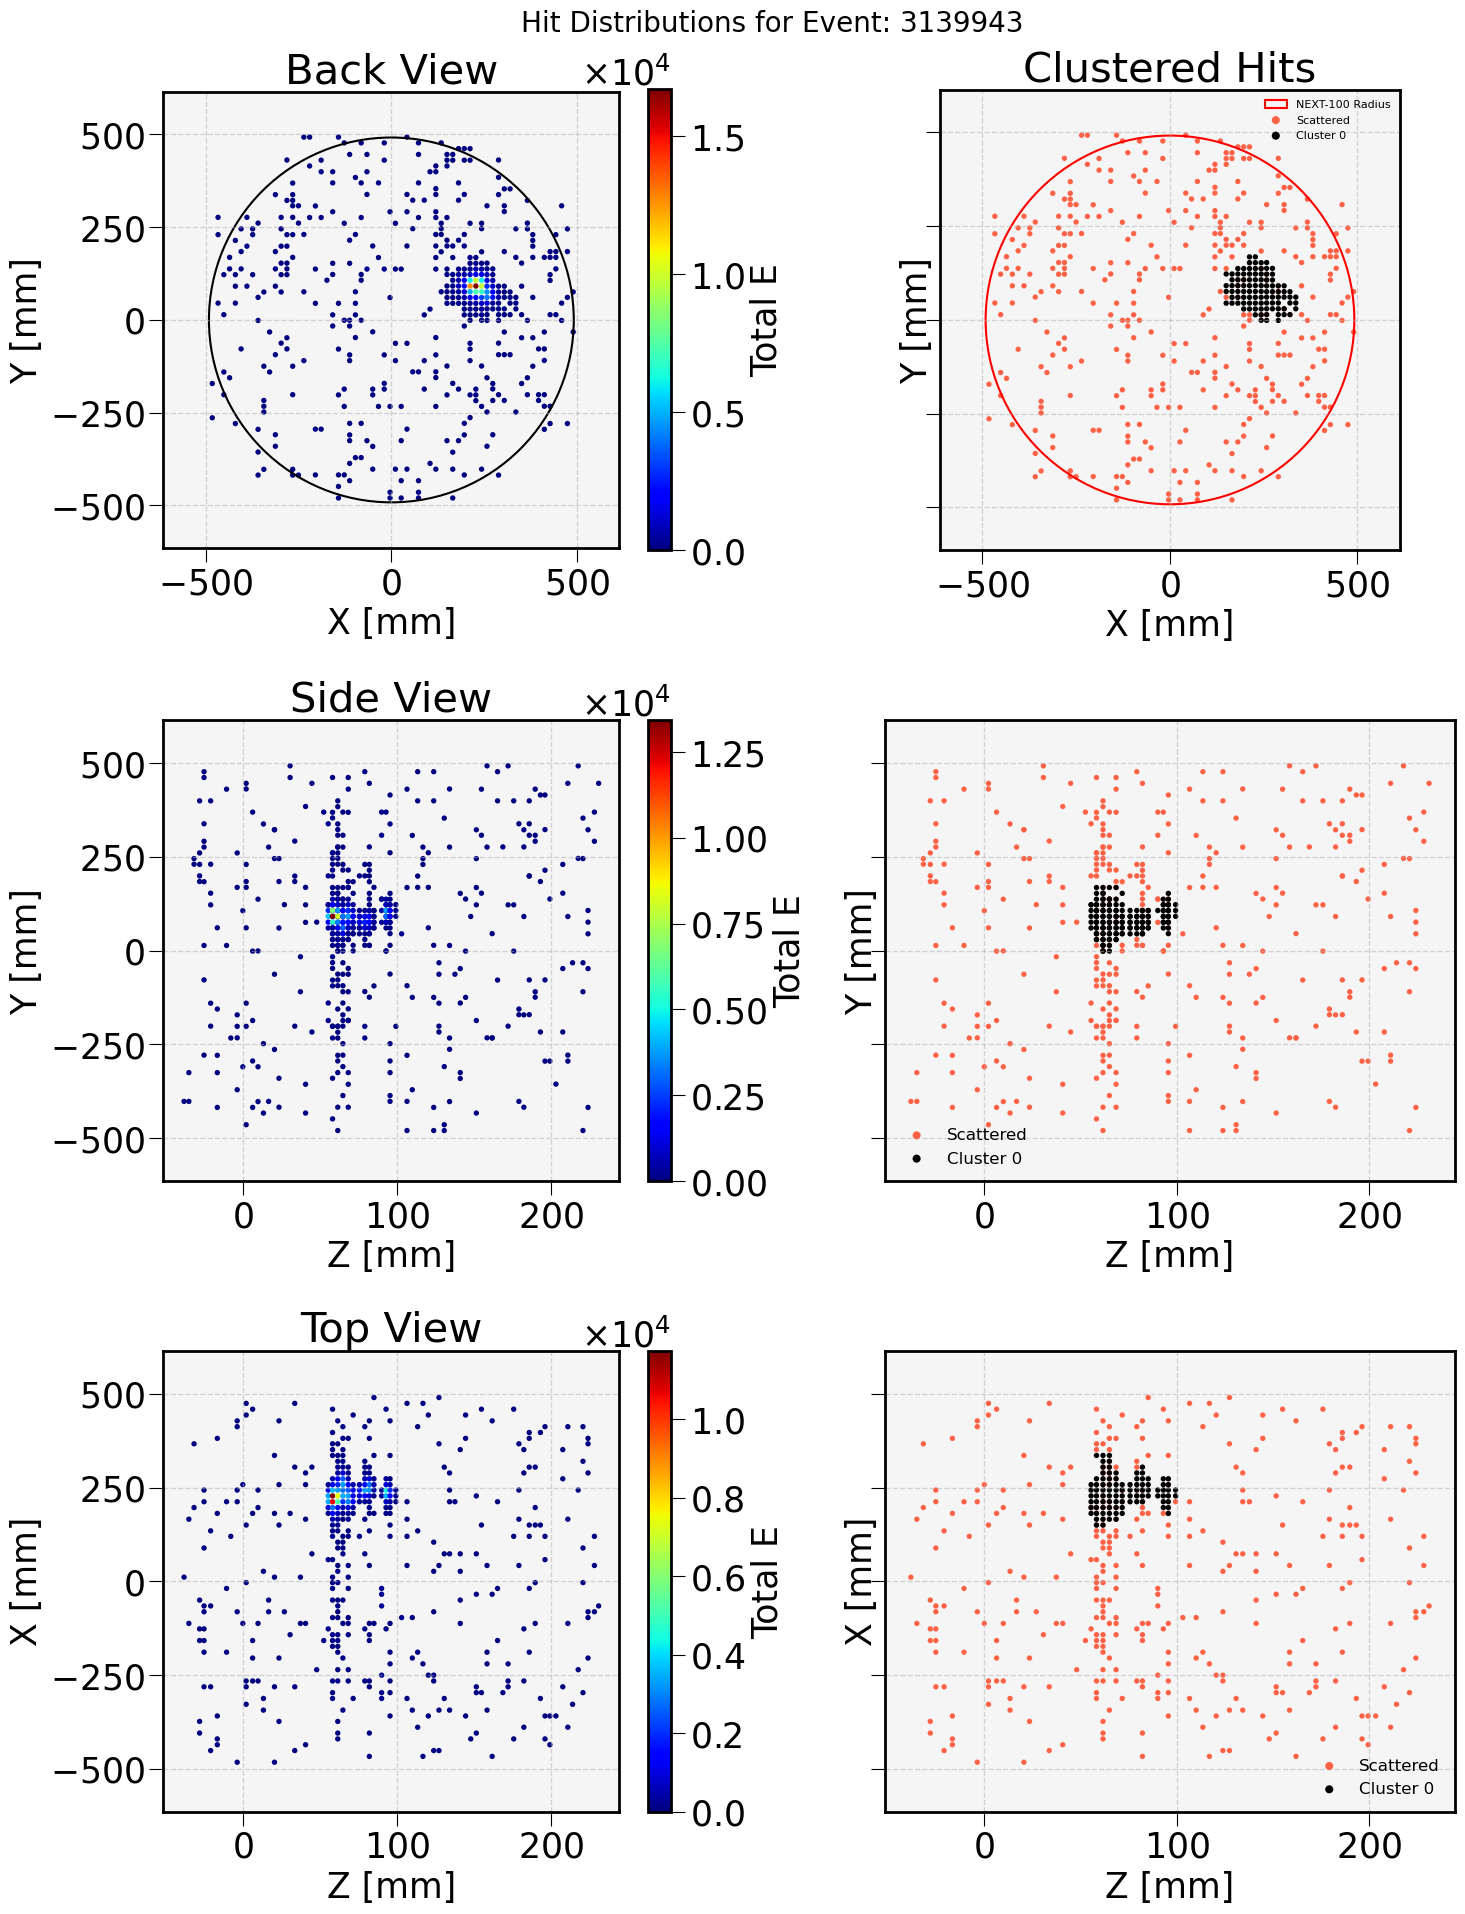

In [119]:
# Pick a random event from the clustered dataframe to visualize its hits
clust_evt_ids = df_soph['event'].unique()
# Event information + visualization
evt_test_id = np.random.choice(clust_evt_ids)
evt_test_id = 3139943
print(f"Event {evt_test_id}:")
crudo.pt.display_event_cluster(df_soph, variable='E', event=evt_test_id)

#### Energy re-distribution

In [116]:
clean_soph_df = crudo.tf.deal_spurious_hits(df_soph, energy_column='E', output_column='E_hit_pe')
print(f"After cleaning spurious hits: {clean_soph_df['event'].nunique()} events")

# Identify events that had only spurious hits and were removed
dead_evts = set(df_soph['event'].unique()) - set(clean_soph_df['event'].unique())
print(f"Removed {len(dead_evts)} events that had only spurious hits: {dead_evts}")

After cleaning spurious hits: 9281 events
Removed 3 events that had only spurious hits: {3094849, 1595084, 106044}


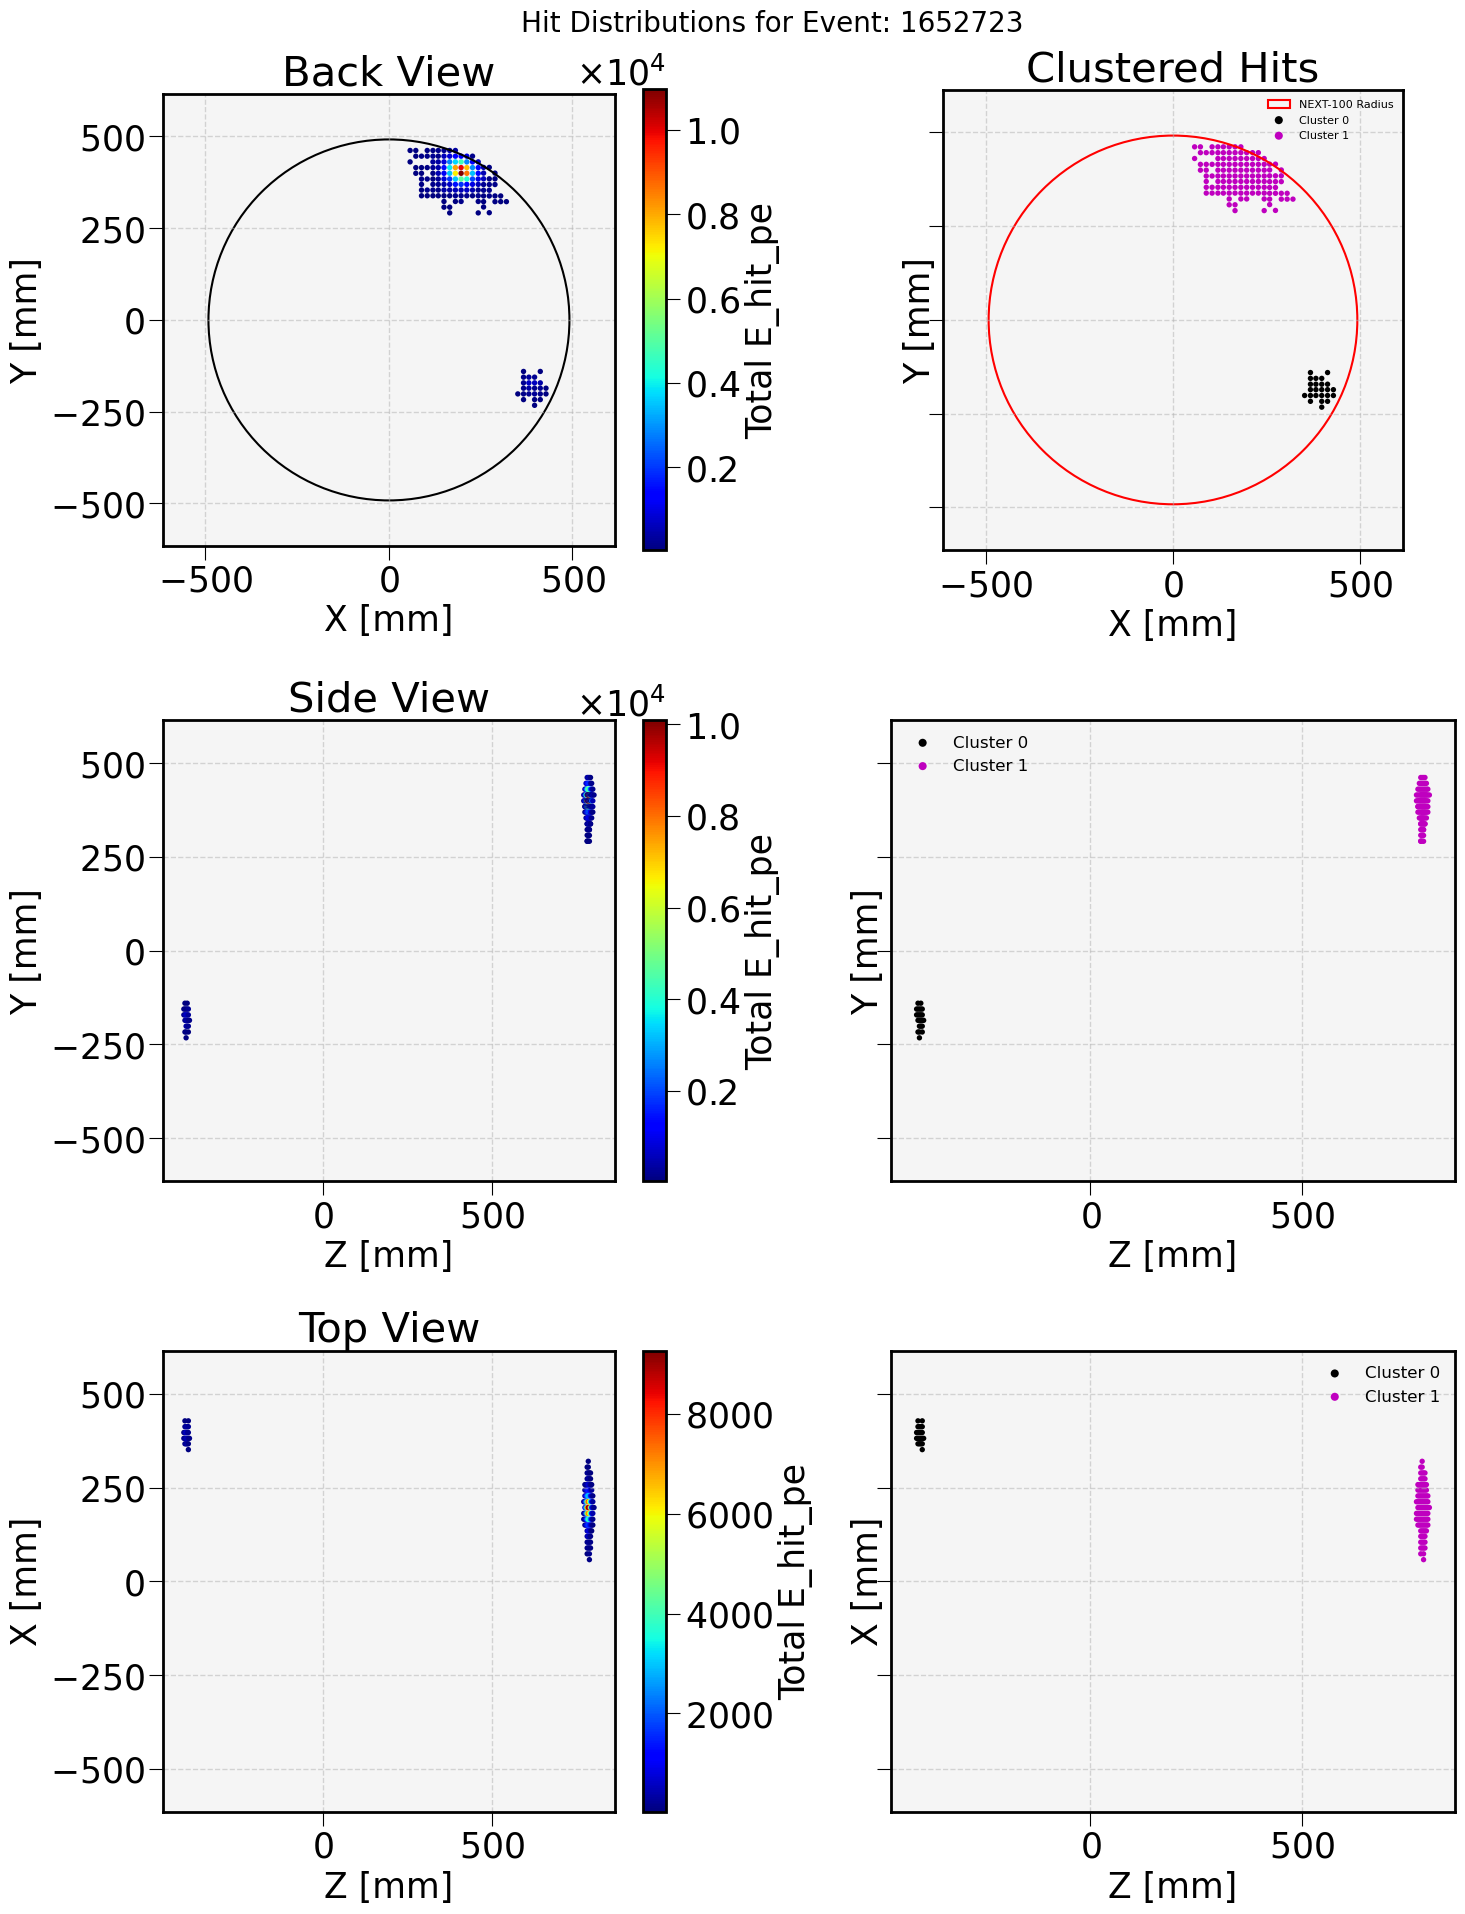

In [165]:
crudo.pt.display_event_cluster(clean_soph_df, variable='E_hit_pe', event=1652723)

In the end, this clean topology is artificial, it depends on the parameters of the clusterizer function.
<br>
I deeem storing the hit size of each event is important, ~~but should be taken from the _original_ Sophronia dataframe.~~

In [121]:
# Hits per event
og_evt_size_df    = df_doro.groupby('event')['old_n_hits'].first().rename('n_hits').reset_index()
clean_evt_size_df = clean_soph_df.groupby('event').size().rename('n_hits').reset_index()

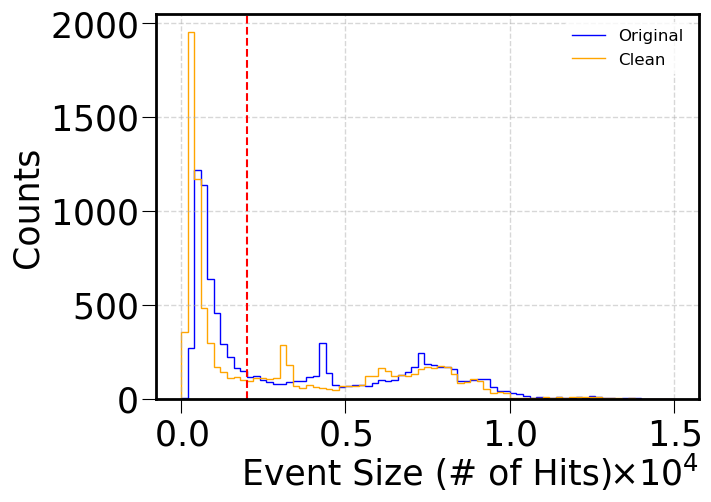

In [124]:
# Histogram
og_hits_counts, edges = np.histogram(og_evt_size_df['n_hits'], bins=75, range=(0, 1.5e4))
cl_hits_counts, _     = np.histogram(clean_evt_size_df['n_hits'], bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(og_hits_counts, edges, fill=False, ec='blue', lw=1.0, label='Original')
plt.stairs(cl_hits_counts, edges, fill=False, ec='orange', lw=1.0, label='Clean')
# Possible hit size cut
plt.axvline(x=SIZE_THRESHOLD, color='red', ls='--', lw=1.5)

# Styling
plt.xlabel('Event Size (# of Hits)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In any case, it is hard to trust in this variable. It suffers the same effect as energy event.
<br>
Some degraded alphas may have lower number of hits (~ electron size).
<br>
Although, this information together with the energies can help us a lot with tagging alpha/electron-like events. So,  I prefer to store the variable from both old and clean Sophronia.

#### Update

In [125]:
# Stay just with (updated) Sophronia dataframe
df_soph = clean_soph_df.copy()
# Update both dataframes
after_hits_treatment_ids = df_soph['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=after_hits_treatment_ids)
print(f"After dealing with spurious hits: {df_soph['event'].nunique()} events")

After dealing with spurious hits: 9281 events


### Removing $Z\leq0$

Remove every event that has hits with negative $Z$ position.
<br>
This is done in Sophronia, although you will find that for some events that passed the Sophronia filter, some $[S1,\,S2]$ peak combinations may still have negative $Z$ value in Dorothea. Due to the unsyncronized peak tagging in both dataframes, we cannot remove especifically those peak combinations in Dorothea.

__NOTE:__ Once the peak tagging will be syncronized, we remove those peak combinations in both dataframe and update $[S1,\,S2]$ multiplicity.

---
__UPDATE:__ As soon as we have again waveforms, we check this guys!

#### Negative events

In [126]:
events_with_negative_z_hits = df_soph.loc[df_soph['Z'] < 0, 'event'].unique()
Z_neg_doro_df, Z_neg_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_with_negative_z_hits)
Z_neg_soph_df

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster,E_hit_pe
110379,25530,1.759157e+09,0,-42.732700,40.020356,1,-451.525,106.475,0.0,0.0,-914.919344,5.264935,36.911798,-1.0,0.000273,-1,-1.0,-791.405232,0,40.306296
110380,25530,1.759157e+09,0,-42.732700,40.020356,1,-435.975,90.925,0.0,0.0,-914.919344,9.531105,66.821379,-1.0,0.000410,-1,-1.0,-791.405232,0,72.966435
110381,25530,1.759157e+09,0,-42.732700,40.020356,1,-435.975,75.375,0.0,0.0,-911.145664,11.307531,171.148067,-1.0,0.001030,-1,-1.0,-788.140999,0,186.887257
110382,25530,1.759157e+09,0,-42.732700,40.020356,1,-435.975,90.925,0.0,0.0,-911.145664,8.887901,134.525130,-1.0,0.000826,-1,-1.0,-788.140999,0,146.896386
110383,25530,1.759157e+09,0,-42.732700,40.020356,1,-435.975,106.475,0.0,0.0,-911.145664,5.329576,80.667177,-1.0,0.000498,-1,-1.0,-788.140999,0,88.085526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29161045,3123360,1.759248e+09,28,-156.205354,160.309540,1,273.325,-171.425,0.0,0.0,75.496375,5.727242,12.477318,-1.0,0.000065,-1,-1.0,65.304364,16,14.116748
29161046,3123360,1.759248e+09,28,-156.205354,160.309540,1,-343.675,337.725,0.0,0.0,80.496625,7.629326,57.989674,-1.0,0.000532,-1,-1.0,69.629581,1,65.609099
29161047,3123360,1.759248e+09,28,-156.205354,160.309540,1,-328.125,322.175,0.0,0.0,80.496625,6.867476,52.198929,-1.0,0.000371,-1,-1.0,69.629581,1,59.057493
29161048,3123360,1.759248e+09,28,-156.205354,160.309540,1,-328.125,337.725,0.0,0.0,80.496625,13.696403,104.104855,-1.0,0.000793,-1,-1.0,69.629581,1,117.783484


In [187]:
Z_neg_doro_df

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,old_n_hits
174,25530,1.759157e+09,0,0,1,2,600.0,148.595688,905.792908,985425.0,...,-902.962280,-902.962280,8.491618,-42.732700,40.020356,58.546670,2.388959,275.440560,253.248957,967
175,25530,1.759157e+09,0,1,1,2,600.0,148.595688,905.792908,985425.0,...,423.063141,423.063141,7.446006,51.997050,-211.914561,218.200537,-1.330182,191.226011,287.148426,967
1140,118280,1.759160e+09,0,0,2,4,1625.0,2.645219,57.461090,1027425.0,...,-980.016296,-980.016296,59.430473,5.714363,19.802753,20.610749,1.289864,261.000712,261.723599,4247
1141,118280,1.759160e+09,0,1,2,4,1625.0,2.645219,57.461090,1027425.0,...,-19.933189,-19.933189,8.701375,-41.460398,-19.609557,45.863922,-2.699801,257.129428,247.976172,4247
1142,118280,1.759160e+09,0,2,2,4,1625.0,2.645219,57.461090,1027425.0,...,169.073380,169.073380,7.362649,-50.029815,47.744471,69.155744,2.379564,258.732823,240.661554,4247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62502,3116738,1.759248e+09,0,0,1,3,350.0,196.205673,1179.227783,479800.0,...,-103.305252,-103.305252,26.350162,8.125681,27.178025,28.366737,1.280276,262.308702,256.962392,1290
62503,3116738,1.759248e+09,0,1,1,3,350.0,196.205673,1179.227783,479800.0,...,930.682434,930.682434,9.952481,65.841560,122.252631,138.855381,1.076771,238.961195,276.361220,1290
62504,3116738,1.759248e+09,0,2,1,3,350.0,196.205673,1179.227783,479800.0,...,1731.687622,1731.687622,6.902792,-6.986197,-7.048486,9.924117,-2.351756,236.280440,243.160298,1290
62508,3123360,1.759248e+09,0,0,1,2,325.0,113.289818,664.044739,1333400.0,...,-1213.931763,-1213.931763,6.338659,-41.757487,46.684778,62.635104,2.300540,279.959406,249.330762,1084


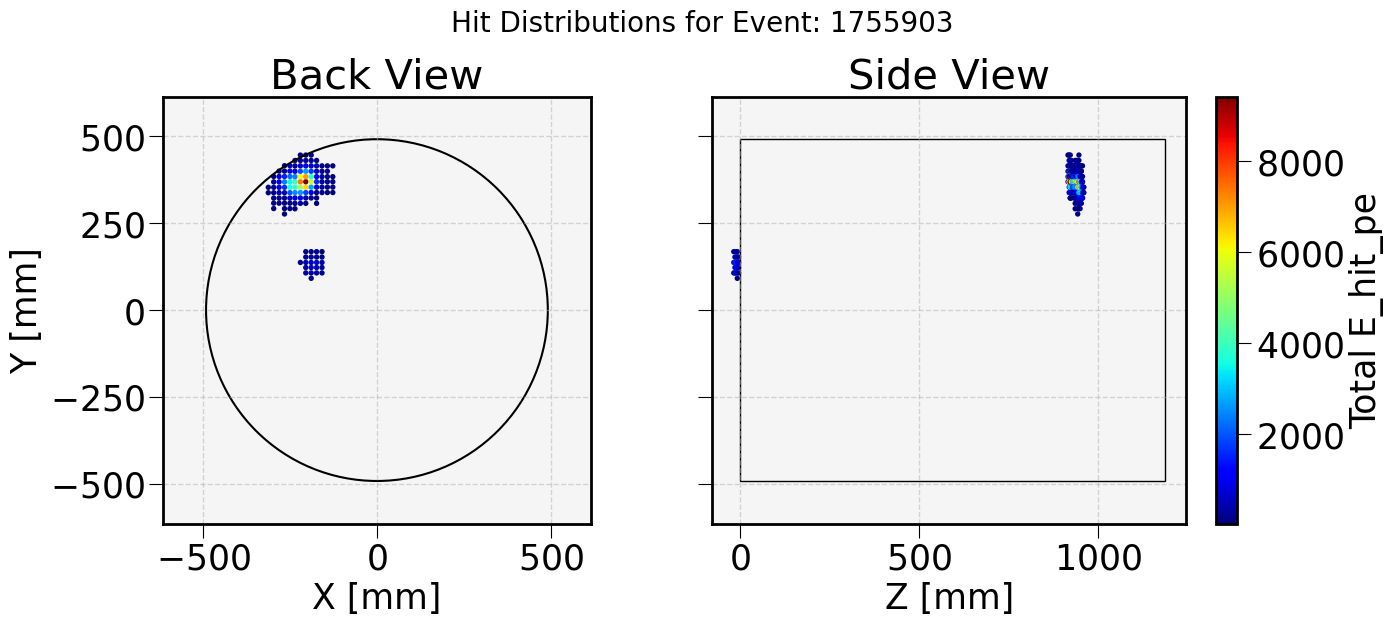

In [186]:
crudo.pt.event_display(Z_neg_soph_df, variable='E_hit_pe', event_column='event', event=None)

#### Positive events

In [188]:
events_with_positive_z_hits = np.setdiff1d(after_hits_treatment_ids, events_with_negative_z_hits)
Z_pos_doro_df, Z_pos_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_with_positive_z_hits)

/lhome/ific/c/ccortesp/Analysis/libs/crudo/plotting_tools.py:328: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  fig.colorbar(scatter_xy, label=f"Total {variable}", fontsize=12, pad=0.02)


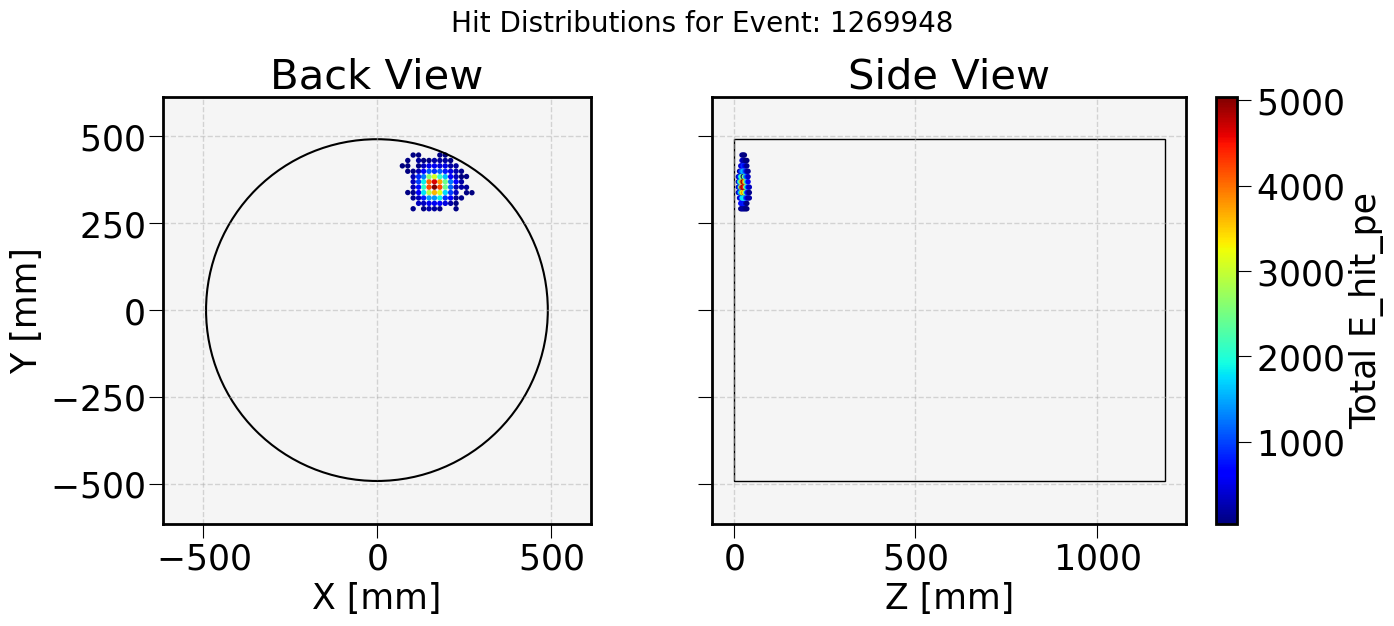

In [208]:
crudo.pt.event_display(Z_pos_soph_df, variable='E_hit_pe', event_column='event', event=1269948)

In [207]:
Z_pos_doro_df

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,old_n_hits
0,323,1.759157e+09,0,0,1,1,575.0,128.524979,762.313965,1209250.0,...,197.237762,197.237762,6.253226,185.209303,-126.474412,224.272742,-0.599139,256.392898,227.020066,1143
1,1667,1.759157e+09,0,0,1,2,1075.0,43.555904,1343.692505,42550.0,...,-0.722445,-0.722445,49.673531,10.994911,18.461657,21.487691,1.033652,259.989078,261.821920,1824
2,1667,1.759157e+09,0,1,1,2,1075.0,43.555904,1343.692505,42550.0,...,1370.942139,1370.942139,9.032280,67.005551,-194.852269,206.051330,-1.239585,177.875383,243.341836,1824
3,1877,1.759157e+09,0,0,1,1,350.0,170.890305,1022.396851,675775.0,...,730.709534,730.709534,8.169236,76.012156,-152.647451,170.525928,-1.108783,220.716443,289.542402,555
4,4173,1.759157e+09,0,0,1,1,350.0,192.267319,1109.293213,976125.0,...,436.362030,436.362030,35.646113,17.890645,101.790312,103.350582,1.396814,216.573688,252.592639,10185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63046,3174159,1.759250e+09,0,0,1,1,700.0,217.700394,1262.090942,293500.0,...,1114.979980,1114.979980,8.563165,-134.464968,29.581635,137.680430,2.925047,294.666126,217.741268,515
63047,3174691,1.759250e+09,0,0,1,1,675.0,228.198990,1394.283936,220925.0,...,1194.565063,1194.565063,8.269702,-9.751355,-265.527942,265.706938,-1.607504,160.130357,262.937504,3658
63048,3174705,1.759250e+09,0,0,1,2,825.0,59.096416,1432.190552,649275.0,...,-607.462280,-607.462280,64.011926,10.271598,14.781150,17.999670,0.963493,260.316810,262.726794,1902
63049,3174705,1.759250e+09,0,1,1,2,825.0,59.096416,1432.190552,649275.0,...,764.212280,764.212280,9.490450,-1.515128,-144.826461,144.834386,-1.581258,182.723960,237.131017,1902


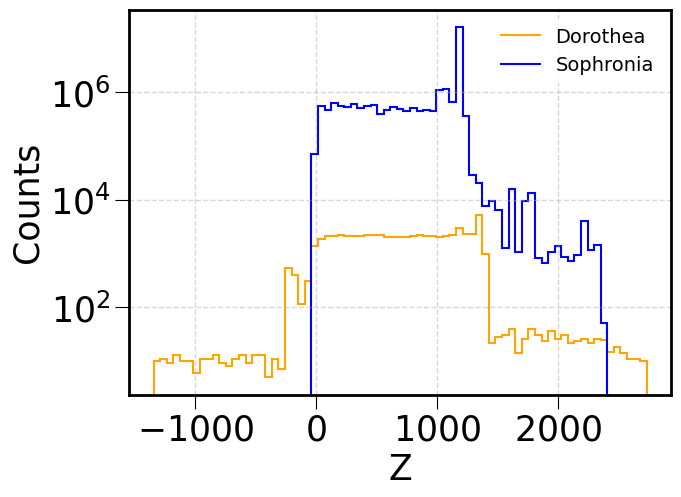

In [205]:
# Drop NaN values from the 'Z' column before creating histograms
Z_doro_clean = Z_pos_doro_df['Z'].dropna()      # nS1 = 0 has NaN Z values
Z_soph_clean = Z_pos_soph_df['Z'].dropna()

# Binning
Z_doro, edges = np.histogram(Z_doro_clean, bins=75)
Z_soph, _     = np.histogram(Z_soph_clean, bins=edges)

plt.figure(figsize=(7, 5))
plt.stairs(Z_doro, edges, fill=False, ec='orange', lw=1.5, label='Dorothea')
plt.stairs(Z_soph, edges, fill=False, ec='blue', lw=1.5, label='Sophronia')
plt.xlabel('Z')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

#### Update

In [176]:
df_doro = Z_pos_doro_df.copy()
df_soph = Z_pos_soph_df.copy()
print(f"After removing events with hits at negative Z: {df_soph['event'].nunique()} events.")

After removing events with hits at negative Z: 4151 events.


### Energy Correction

Correction value @ center of anode: [0.97570246]


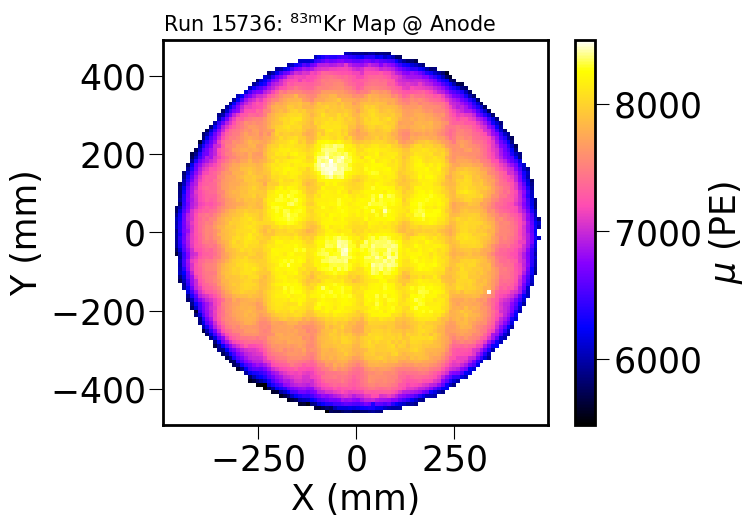

In [222]:
# Select the Kr file you want to use
kr_test_path = KR_PATH

# Kr map loading
kr_map_df = pd.read_hdf(kr_test_path, key='krmap/krmap')    # 'krmap/krmap' or just 'krmap'

# Check the map in the anode region (k=0)
zem_map = kr_map_df[kr_map_df['k'] == 0].copy()
plt.figure(figsize=(7, 5))
plt.imshow(zem_map['mu'].values.reshape(100, 100).T, origin='lower', extent=(-crudo.pt.N100_rad, crudo.pt.N100_rad, -crudo.pt.N100_rad, crudo.pt.N100_rad))
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.colorbar(label=r'$\mu$ (PE)')
plt.title(rf"Run {RUN_NUMBER}: $^{{83\mathrm{{m}}}}$Kr Map @ Anode", fontsize=15, loc='left')

corr3d = crudo.ef.get_corr3d(kr_test_path, norm_method=NormMethod.median_anode)     # If this fails look at the used key in the function
print(f'Correction value @ center of anode: {corr3d([0], [0], [0])}')

In [223]:
# How is the time evolution of energy scale?
kr_time_df = pd.read_hdf(kr_test_path, key='t_evol/t_evol')
kr_time_df.ts.value_counts()

1759156589    1
1759163789    1
1759170989    1
1759178189    1
1759185389    1
1759192589    1
1759199789    1
1759206989    1
1759214189    1
1759221389    1
1759228589    1
1759235789    1
1759242989    1
Name: ts, dtype: int64

#### Apply $^{83\text{m}}\text{Kr}$ correction

In [179]:
df_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster,E_hit_pe
0,729,1.758896e+09,0,70.205942,5.904926,1,-235.825,353.775,0.0,0.0,1399.086269,5.810370,268.245727,-1.0,0.001678,-1,-1.0,1210.209623,0,268.440656
1,729,1.758896e+09,0,70.205942,5.904926,1,-112.425,-417.725,0.0,0.0,1399.086269,5.485558,253.250183,-1.0,0.001634,-1,-1.0,1210.209623,0,253.434214
2,729,1.758896e+09,0,70.205942,5.904926,1,181.025,122.525,0.0,0.0,1399.086269,6.172557,284.966708,-1.0,0.001525,-1,-1.0,1210.209623,0,285.173787
3,729,1.758896e+09,0,70.205942,5.904926,1,-373.775,-279.275,0.0,0.0,1402.239644,7.429824,156.612494,-1.0,0.001241,-1,-1.0,1212.937292,0,156.726300
4,729,1.758896e+09,0,70.205942,5.904926,1,-389.325,-93.675,0.0,0.0,1402.239644,6.564920,138.381264,-1.0,0.000797,-1,-1.0,1212.937292,0,138.481822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13672463,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,214.325,0.0,0.0,1368.305500,7.229555,6.293980,-1.0,0.000043,-1,-1.0,1183.584257,0,6.294388
13672464,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,229.875,0.0,0.0,1368.305500,7.330564,6.381917,-1.0,0.000046,-1,-1.0,1183.584257,0,6.382331
13672465,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,245.425,0.0,0.0,1368.305500,6.875893,5.986085,-1.0,0.000046,-1,-1.0,1183.584257,0,5.986474
13672466,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,260.975,0.0,0.0,1368.305500,10.088025,8.782536,-1.0,0.000077,-1,-1.0,1183.584257,0,8.783106


In [224]:
# Apply Kr correction & clean negative/NaN values
corr_soph = crudo.ef.correct_energy_by_kr_map( df_soph
                                             , kr_test_path
                                             , norm_method = NormMethod.median_anode
                                             , city = KR_CITY
                                             , mev_units  = True
                                             , energy_col = 'E_hit_pe'
                                             , output_col = 'Ec' )

corr_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster,E_hit_pe
0,323,1.759157e+09,36,185.209305,-126.474414,1,381.175,-279.275,0.0,0.0,188.916875,14.938734,291.513716,-1.0,0.002194,-1,-1.0,163.413097,0,319.145663
1,323,1.759157e+09,36,185.209305,-126.474414,1,396.725,-279.275,0.0,0.0,188.916875,8.404098,163.997143,-1.0,0.001234,-1,-1.0,163.413097,0,179.542073
2,323,1.759157e+09,36,185.209305,-126.474414,1,243.225,-247.675,0.0,0.0,192.505375,5.304232,61.563901,-1.0,0.000367,-1,-1.0,166.517149,0,67.399408
3,323,1.759157e+09,36,185.209305,-126.474414,1,196.575,-63.075,0.0,0.0,192.505375,10.432484,121.085283,-1.0,0.000673,-1,-1.0,166.517149,7,132.562692
4,323,1.759157e+09,36,185.209305,-126.474414,1,335.525,-309.375,0.0,0.0,192.505375,7.626921,88.522339,-1.0,0.000605,-1,-1.0,166.517149,0,96.913177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29357276,3175314,1.759250e+09,26,-3.696408,226.041072,1,-19.125,477.175,0.0,0.0,195.242125,54.858704,243.767740,-1.0,0.001798,-1,-1.0,168.884438,0,261.761837
29357277,3175314,1.759250e+09,26,-3.696408,226.041072,1,-19.125,492.725,0.0,0.0,195.242125,22.408291,99.572503,-1.0,0.000735,-1,-1.0,168.884438,0,106.922603
29357278,3175314,1.759250e+09,26,-3.696408,226.041072,1,-3.575,461.625,0.0,0.0,195.242125,15.202615,67.553675,-1.0,0.000512,-1,-1.0,168.884438,0,72.540255
29357279,3175314,1.759250e+09,26,-3.696408,226.041072,1,-3.575,477.175,0.0,0.0,195.242125,16.819590,74.738794,-1.0,0.000567,-1,-1.0,168.884438,0,80.255755


What does the corrected energy spectrum look like now?

In [225]:
# Dataframe with energy per peak per event
event_df = corr_soph.groupby(['event']).agg(
                                                # Uncorrected
                                                X = ('X', lambda x: crudo.ut.weighted_avg(x, corr_soph.loc[x.index, 'E_hit_pe'])),
                                                Y = ('Y', lambda y: crudo.ut.weighted_avg(y, corr_soph.loc[y.index, 'E_hit_pe'])),
                                                Z = ('Z', lambda z: crudo.ut.weighted_avg(z, corr_soph.loc[z.index, 'E_hit_pe'])),
                                                E_evt = ('E_hit_pe', 'sum'), 
                                                # Corrected
                                                Xc = ('X', lambda x: crudo.ut.weighted_avg(x, corr_soph.loc[x.index, 'Ec'])),
                                                Yc = ('Y', lambda y: crudo.ut.weighted_avg(y, corr_soph.loc[y.index, 'Ec'])),
                                                Zc = ('Z', lambda z: crudo.ut.weighted_avg(z, corr_soph.loc[z.index, 'Ec'])),
                                                Ec_evt = ('Ec', 'sum')).reset_index()

event_df

,event,X,Y,Z,E_evt,Xc,Yc,Zc,Ec_evt
0,323,360.167522,-262.244535,170.737974,1.986672e+05,364.354752,-265.292894,170.735415,1.299100
1,450,-104.916242,53.773801,1071.158244,1.146882e+06,-103.085991,52.770551,1071.163302,6.162853
2,891,-305.235110,112.321153,1184.723455,3.676884e+05,-306.259098,112.695684,1184.720729,2.041302
3,1066,217.557930,75.193000,1185.283343,9.488139e+05,217.719782,74.960569,1185.291068,5.247950
4,1591,-46.660568,-445.460083,49.090256,9.681824e+04,-46.092944,-446.704784,49.309786,0.631782
...,...,...,...,...,...,...,...,...,...
9276,3173339,379.944105,-107.428977,77.310551,2.366022e+05,392.448578,-110.738045,77.284355,1.507129
9277,3174159,-442.259199,64.664087,963.673441,7.357061e+04,-443.074784,64.180946,963.669346,0.483502
9278,3174691,-14.846755,-384.196535,1034.038347,5.604914e+05,-15.361254,-393.706767,1034.023386,3.619159
9279,3174705,-3.749422,-297.585194,661.437971,2.907698e+05,-3.758731,-298.461750,661.442919,1.570279


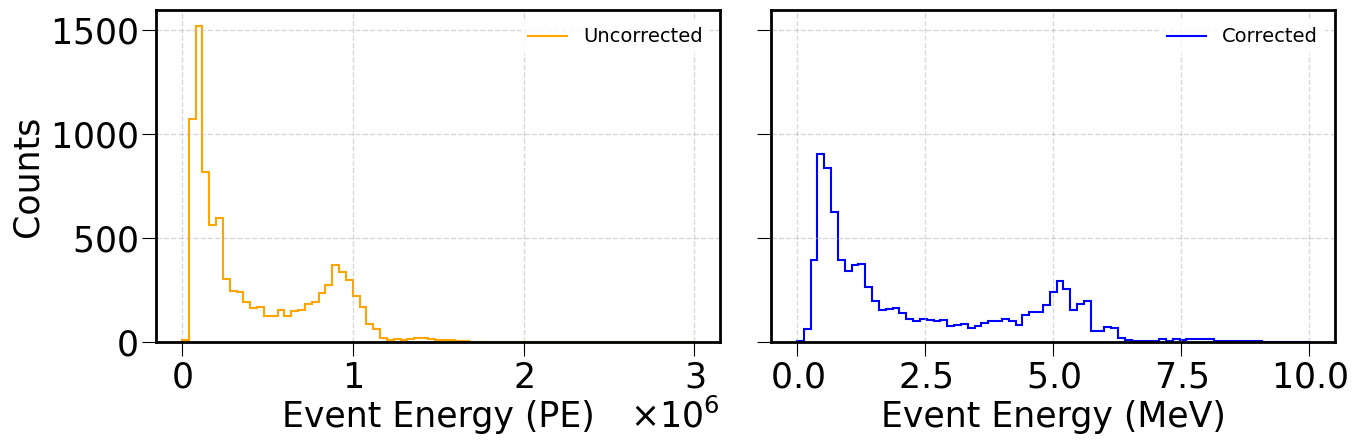

In [227]:
# Histogram
E_counts, e   = np.histogram(event_df['E_evt'], bins=75, range=(0, 3e6))
Ec_counts, ec = np.histogram(event_df['Ec_evt'], bins=75, range=(0, 10))

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot uncorrected energy histogram
axes[0].stairs(E_counts, e, fill=False, ec='orange', lw=1.5, label='Uncorrected')
axes[0].set_xlabel('Event Energy (PE)')
axes[0].set_ylabel('Counts')
axes[0].legend(fontsize=14)
axes[0].grid(True)

# Plot corrected energy histogram
axes[1].stairs(Ec_counts, ec, fill=False, ec='blue', lw=1.5, label='Corrected')
axes[1].set_xlabel('Event Energy (MeV)')
axes[1].legend(fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Update

In [230]:
# New dataframe with corrected energy per hit
df_soph = corr_soph.copy()

after_energy_correction_ids = df_soph['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=after_energy_correction_ids)
print(f"After Kr energy correction: {df_soph['event'].nunique()} events")

After Kr energy correction: 9281 events


### $S1e$ Cut & Correction

#### $nS1\,\leq\,1$ (NO-Polike)

In [266]:
s1_mask = (df_doro['nS1'] == 0) | ((df_doro['nS1'] == 1))
S1_doro_df, S1_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, cut_mask=s1_mask, df_for_mask=df_doro)

In [232]:
S1_doro_df['nS1'].value_counts()

1    6508
0     839
Name: nS1, dtype: int64

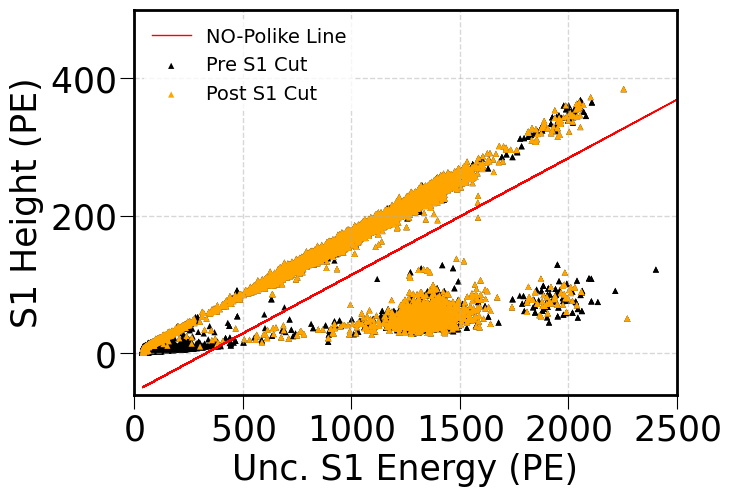

In [267]:
plt.figure(figsize=(7, 5))
plt.scatter(df_doro['S1e'],       df_doro['S1h'], s=20, marker='^',  c='black', ec='none', label='Pre S1 Cut')
plt.scatter(S1_doro_df['S1e'], S1_doro_df['S1h'], s=20, marker='^', c='orange', ec='none', label='Post S1 Cut')
plt.plot(df_doro['S1e'], M_NOPOLIKE * df_doro['S1e'] + B_NOPOLIKE, c='red', ls='-', lw=1.0, label='NO-Polike Line')
plt.xlabel('Unc. S1 Energy (PE)')
plt.xlim(0, 2.5e3)
plt.ylabel('S1 Height (PE)')
plt.ylim(-60, 500)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

#### $S1e$ correction

In [268]:
S1_corr_doro_df = crudo.ef.correct_S1e(S1_doro_df, CV_FIT, DT_CATH, output_column='S1e_corr')     # Based on alpha analysis

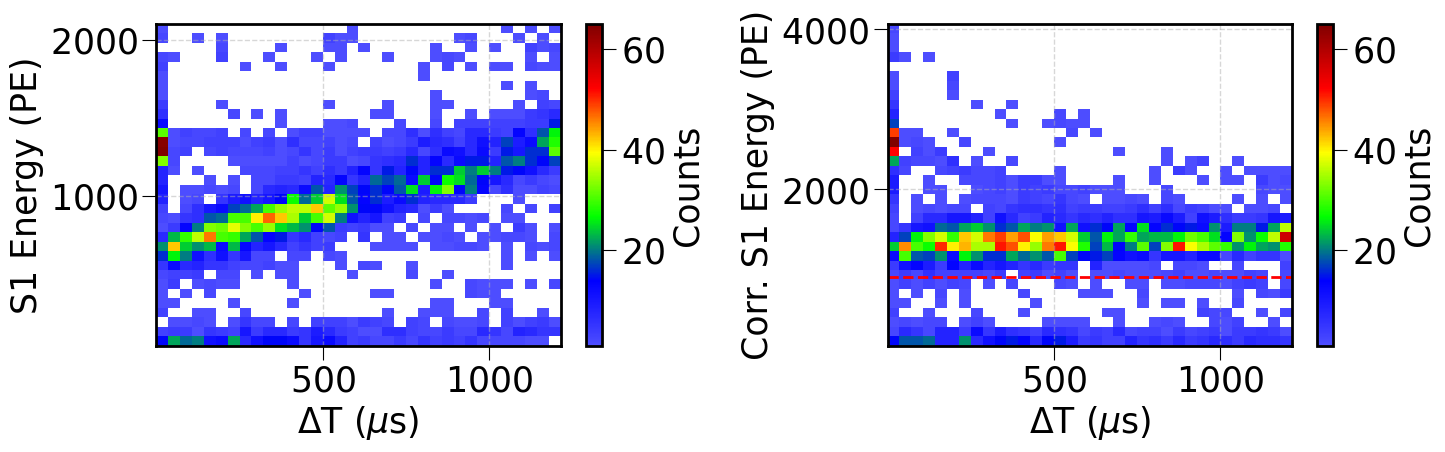

In [271]:
n_bins = 35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, col in enumerate(['S1e', 'S1e_corr']):

    # Variables
    E1 = S1_corr_doro_df[col]
    DT = S1_corr_doro_df['DT']
    R = np.sqrt(S1_corr_doro_df['X']**2 + S1_corr_doro_df['Y']**2)

    # Masking
    rad_mask  = (R  < R_UP)
    time_mask = (DT >= 0) & (DT < 0.9*DT_CATH)
    E1 = E1[rad_mask & time_mask]
    DT = DT[rad_mask & time_mask]

    # 2D histogram
    S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT, E1, x_bins=n_bins, y_bins=n_bins)
    S1e_DT_map = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)

    im = axes[i].pcolormesh(ex, ey, S1e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(im, ax=axes[i], label='Counts', shrink=1.0)
    axes[i].set_xlabel('$\Delta$T ($\mu$s)')
    axes[i].set_ylabel('Corr. S1 Energy (PE)' if col == 'S1e_corr' else 'S1 Energy (PE)')
    axes[i].grid(True)

    # Possible alpha/electron limit line
    if col == 'S1e_corr':
        axes[i].axhline(y=S1_ENERGY_THRESHOLD, color='red', ls='--')

plt.tight_layout()
plt.show()

Max. corrected $S1$ energy per event would be our main discriminator for alpha/electron tagging!
<br>
In particular, for events with bad energy $(S2)$ reconstruction (~ cathode region, where we have degraded alphas).

#### Update

In [ ]:
df_doro = S1_corr_doro_df.copy()
df_soph = S1_soph_df.copy()

print(f"After S1 cut & correction: {df_soph['event'].nunique()} events")

After S1 cut & correction: 7656 events.


### Data @ Event/Peak-level

#### From Dorothea

In [273]:
# df_doro.event.nunique()
df_doro

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,old_n_hits,S1e_corr
0,323,1.759157e+09,0,0,1,1,575.0,128.524979,762.313965,1209250.0,...,197.237762,6.253226,185.209303,-126.474412,224.272742,-0.599139,256.392898,227.020066,1143,1313.382785
1,1667,1.759157e+09,0,0,1,2,1075.0,43.555904,1343.692505,42550.0,...,-0.722445,49.673531,10.994911,18.461657,21.487691,1.033652,259.989078,261.821920,1824,2643.153689
2,1667,1.759157e+09,0,1,1,2,1075.0,43.555904,1343.692505,42550.0,...,1370.942139,9.032280,67.005551,-194.852269,206.051330,-1.239585,177.875383,243.341836,1824,1333.527728
3,1877,1.759157e+09,0,0,1,1,350.0,170.890305,1022.396851,675775.0,...,730.709534,8.169236,76.012156,-152.647451,170.525928,-1.108783,220.716443,289.542402,555,1319.916480
4,4173,1.759157e+09,0,0,1,1,350.0,192.267319,1109.293213,976125.0,...,436.362030,35.646113,17.890645,101.790312,103.350582,1.396814,216.573688,252.592639,10185,1661.971667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63046,3174159,1.759250e+09,0,0,1,1,700.0,217.700394,1262.090942,293500.0,...,1114.979980,8.563165,-134.464968,29.581635,137.680430,2.925047,294.666126,217.741268,515,1380.151966
63047,3174691,1.759250e+09,0,0,1,1,675.0,228.198990,1394.283936,220925.0,...,1194.565063,8.269702,-9.751355,-265.527942,265.706938,-1.607504,160.130357,262.937504,3658,1477.895662
63048,3174705,1.759250e+09,0,0,1,2,825.0,59.096416,1432.190552,649275.0,...,-607.462280,64.011926,10.271598,14.781150,17.999670,0.963493,260.316810,262.726794,1902,4981.058013
63049,3174705,1.759250e+09,0,1,1,2,825.0,59.096416,1432.190552,649275.0,...,764.212280,9.490450,-1.515128,-144.826461,144.834386,-1.581258,182.723960,237.131017,1902,1820.304310


In [277]:
doro_info_df = crudo.dm.summarize_dorothea_info(df_doro, event_level_cols=EVENT_LEVEL_COLS)
doro_info_df

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
0,323,1,1,1143,1.759157e+09,762.313965,1313.382785,575.0,128.524979,1209250.0,2.027807e+05,119.000,26925.199219,1.406488e+06,52303.546875
1,450,1,1,10018,1.759157e+09,1603.607910,1671.370030,850.0,269.178802,178875.0,1.156508e+06,140.000,68836.968750,1.417487e+06,258488.437500
2,1066,1,1,7983,1.759157e+09,1308.560181,1299.132857,375.0,226.088440,48550.0,9.578909e+05,150.825,53060.593750,1.418487e+06,203714.187500
3,1591,1,1,549,1.759157e+09,93.521263,176.979598,575.0,17.189184,1353075.0,9.878611e+04,120.700,9579.250977,1.407473e+06,33683.335938
4,1667,1,2,1824,1.759157e+09,1343.692505,2643.153689,1075.0,43.555904,42550.0,6.240240e+03,213.350,1334.099976,4.182755e+04,26874.777344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9329,3174159,1,1,515,1.759250e+09,1262.090942,1380.151966,700.0,217.700394,293500.0,7.487341e+04,168.100,4611.328613,1.408480e+06,33844.597656
9330,3174691,1,1,3658,1.759250e+09,1394.283936,1477.895662,675.0,228.198990,220925.0,5.680370e+05,135.100,33775.160156,1.415490e+06,141018.656250
9331,3174705,1,2,1902,1.759250e+09,1432.190552,4981.058013,825.0,59.096416,649275.0,6.642209e+03,216.000,1442.126099,4.181273e+04,30535.357422
9332,3174705,1,2,1902,1.759250e+09,1432.190552,1820.304310,825.0,59.096416,649275.0,2.953272e+05,167.575,16599.144531,1.413487e+06,76673.140625


In [279]:
doro_info_df.nunique()

event         7656
nS1              2
nS2              6
old_n_hits    4086
time          7656
S1e           6914
S1e_corr      8495
S1w             61
S1h           6914
S1t           5041
S2e           9334
S2w           5288
S2h           9333
S2t           4097
S2q           9332
dtype: int64

#### From Sophronia (NO spurious hits)

In [420]:
df_soph = df_soph.loc[:, FINAL_SOPH_COLUMNS].copy()
df_soph

,event,time,npeak,X,Y,DT,Z,Ec,cluster
0,323,1.759157e+09,36,381.175,-279.275,188.916875,163.413097,0.002194,0
1,323,1.759157e+09,36,396.725,-279.275,188.916875,163.413097,0.001234,0
2,323,1.759157e+09,36,243.225,-247.675,192.505375,166.517149,0.000367,0
3,323,1.759157e+09,36,196.575,-63.075,192.505375,166.517149,0.000673,7
4,323,1.759157e+09,36,335.525,-309.375,192.505375,166.517149,0.000605,0
...,...,...,...,...,...,...,...,...,...
29357276,3175314,1.759250e+09,26,-19.125,477.175,195.242125,168.884438,0.001798,0
29357277,3175314,1.759250e+09,26,-19.125,492.725,195.242125,168.884438,0.000735,0
29357278,3175314,1.759250e+09,26,-3.575,461.625,195.242125,168.884438,0.000512,0
29357279,3175314,1.759250e+09,26,-3.575,477.175,195.242125,168.884438,0.000567,0


In [282]:
soph_event_info_df = crudo.dm.summarize_hits_to_event_level(df_soph, energy_column='Ec')
soph_event_info_df

,event,E_evt,n_cluster,n_hits,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,323,1.299100,24,677,364.354752,-265.292894,170.735415,-297.025,458.925,-464.375,291.575,163.413097,179.322826,502.578458
1,450,6.162853,1,9899,-103.085991,52.770551,1071.163302,-482.625,490.025,-479.925,492.725,1050.645651,1091.587939,510.216784
2,1066,5.247950,2,7833,217.719782,74.960569,1185.291068,-482.625,490.025,-479.925,492.725,1165.965829,1206.924985,498.389262
3,1591,0.631782,2,351,-46.092944,-446.704784,49.309786,-158.075,73.175,-479.925,-356.525,39.059832,72.838731,486.766639
4,1667,1.599880,9,1115,117.453839,-356.121904,1186.748429,-235.825,381.175,-479.925,245.925,1170.258284,1207.719488,489.985317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7651,3173339,1.507129,46,1274,392.448578,-110.738045,77.284355,-435.975,490.025,-464.375,430.525,71.779863,87.798365,509.721106
7652,3174159,0.483502,1,311,-443.074784,64.180946,963.669346,-482.625,-343.675,-62.575,153.125,949.784921,980.177561,491.115309
7653,3174691,3.619159,25,3365,-15.361254,-393.706767,1034.023386,-435.975,490.025,-479.925,446.075,1017.704938,1051.630454,494.520987
7654,3174705,1.570279,16,1106,-3.758731,-298.461750,661.442919,-389.325,381.175,-479.925,199.275,642.787555,680.294063,482.545911


In [48]:
# soph_peak_info_df = df_final_soph.groupby(['event', 'npeak']).agg(E_peak_pe = ('E_hit_pe', 'sum')).reset_index()
# soph_peak_info_df

#### Aggregate

In [283]:
# df_file = pd.merge(soph_peak_info_df, soph_event_info_df, on='event', how='left')
df_file = pd.merge(doro_info_df, soph_event_info_df, on='event', how='left')
df_file

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,323,1,1,1143,1.759157e+09,762.313965,1313.382785,575.0,128.524979,1209250.0,...,364.354752,-265.292894,170.735415,-297.025,458.925,-464.375,291.575,163.413097,179.322826,502.578458
1,450,1,1,10018,1.759157e+09,1603.607910,1671.370030,850.0,269.178802,178875.0,...,-103.085991,52.770551,1071.163302,-482.625,490.025,-479.925,492.725,1050.645651,1091.587939,510.216784
2,1066,1,1,7983,1.759157e+09,1308.560181,1299.132857,375.0,226.088440,48550.0,...,217.719782,74.960569,1185.291068,-482.625,490.025,-479.925,492.725,1165.965829,1206.924985,498.389262
3,1591,1,1,549,1.759157e+09,93.521263,176.979598,575.0,17.189184,1353075.0,...,-46.092944,-446.704784,49.309786,-158.075,73.175,-479.925,-356.525,39.059832,72.838731,486.766639
4,1667,1,2,1824,1.759157e+09,1343.692505,2643.153689,1075.0,43.555904,42550.0,...,117.453839,-356.121904,1186.748429,-235.825,381.175,-479.925,245.925,1170.258284,1207.719488,489.985317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9329,3174159,1,1,515,1.759250e+09,1262.090942,1380.151966,700.0,217.700394,293500.0,...,-443.074784,64.180946,963.669346,-482.625,-343.675,-62.575,153.125,949.784921,980.177561,491.115309
9330,3174691,1,1,3658,1.759250e+09,1394.283936,1477.895662,675.0,228.198990,220925.0,...,-15.361254,-393.706767,1034.023386,-435.975,490.025,-479.925,446.075,1017.704938,1051.630454,494.520987
9331,3174705,1,2,1902,1.759250e+09,1432.190552,4981.058013,825.0,59.096416,649275.0,...,-3.758731,-298.461750,661.442919,-389.325,381.175,-479.925,199.275,642.787555,680.294063,482.545911
9332,3174705,1,2,1902,1.759250e+09,1432.190552,1820.304310,825.0,59.096416,649275.0,...,-3.758731,-298.461750,661.442919,-389.325,381.175,-479.925,199.275,642.787555,680.294063,482.545911


I do not put $S1$ energy @ peak-level cause' the unsyncronized tag of peaks between Dorothea and Sophronia

# Tagging

Now, with the final dataframes we can inspect the tagging of events by particle type and detector region.

## By Particle

Recall, we still have degradated alphas, so we need to establish a proper way to distinguish alphas from electrons

In [284]:
zero_s1_events_df = df_file[df_file['nS1'] == 0].copy()
print(f"Events with zero S1: {zero_s1_events_df['event'].nunique()} ({zero_s1_events_df['event'].nunique() / df_file['event'].nunique() :.2%})")
one_s1_events_df  = df_file[df_file['nS1'] == 1].copy()
print(f"Events with one S1: {one_s1_events_df['event'].nunique()} ({one_s1_events_df['event'].nunique() / df_file['event'].nunique() :.2%})")

Events with zero S1: 741 (9.68%)
Events with one S1: 6915 (90.32%)


Take a look to the energy spectrum

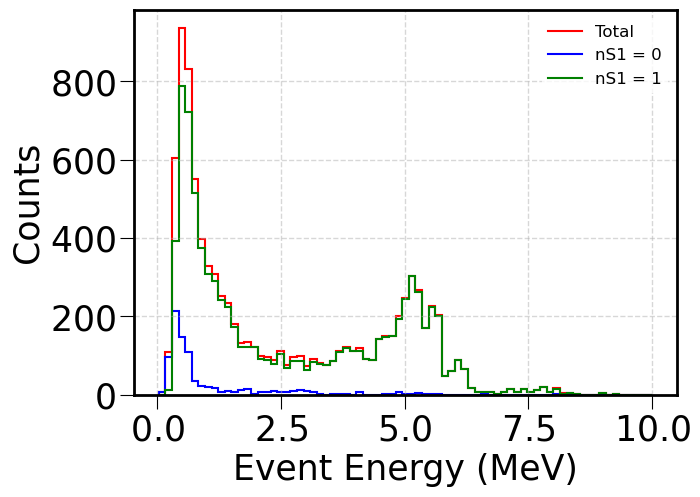

In [285]:
# Histogram
all_evt_counts, edges = np.histogram(df_file['E_evt'], bins=75, range=(df_file['E_evt'].min(), 10))
zero_s1_evt_counts, _ = np.histogram(zero_s1_events_df['E_evt'], bins=edges)
one_s1_evt_counts, _  = np.histogram(one_s1_events_df['E_evt'], bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(all_evt_counts, edges, fill=False, ec='red', lw=1.5, label='Total')
plt.stairs(zero_s1_evt_counts, edges, fill=False, ec='blue', lw=1.5, label='nS1 = 0')
plt.stairs(one_s1_evt_counts, edges, fill=False, ec='green', lw=1.5, label='nS1 = 1')

# Styling
plt.xlabel('Event Energy (MeV)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

### $nS1 = 0$

In this case a good discriminator would be the _event size_ (# of hits)

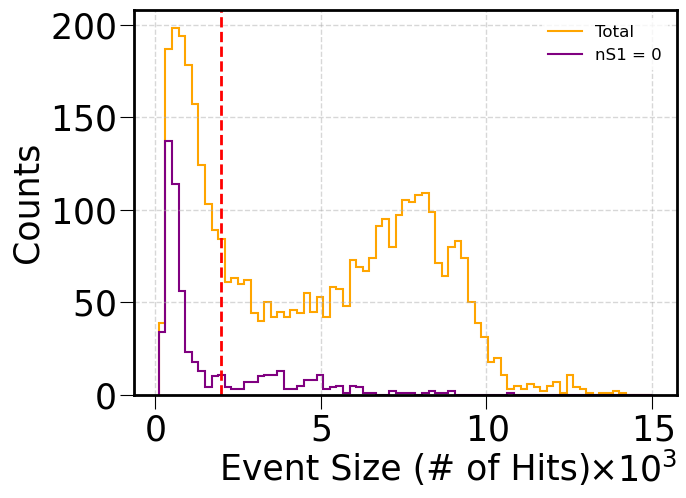

In [286]:
# Histogram
evt_counts, edges = np.histogram(df_file['old_n_hits'].unique(), bins=75, range=(df_file['old_n_hits'].min(), 15e3))
zero_s1_counts, _ = np.histogram(zero_s1_events_df['old_n_hits'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(evt_counts, edges, fill=False, ec='orange', lw=1.5, label='Total')
plt.stairs(zero_s1_counts, edges, fill=False, ec='purple', lw=1.5, label='nS1 = 0')
# Event size cut
plt.axvline(x=SIZE_THRESHOLD, color='red', ls='--')

# Styling
plt.xlabel('Event Size (# of Hits)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [287]:
zero_s1_elec_like  = zero_s1_events_df.loc[zero_s1_events_df['old_n_hits'] <= SIZE_THRESHOLD, 'event'].unique()
zero_s1_alpha_like = zero_s1_events_df.loc[zero_s1_events_df['old_n_hits'] >  SIZE_THRESHOLD, 'event'].unique()
print(f"Number of electron-like events: {len(zero_s1_elec_like)} ({len(zero_s1_elec_like) / zero_s1_events_df['event'].nunique() :.2%})")
print(f"Number of alpha-like events: {len(zero_s1_alpha_like)} ({len(zero_s1_alpha_like) / zero_s1_events_df['event'].nunique() :.2%})")

Number of electron-like events: 588 (79.35%)
Number of alpha-like events: 153 (20.65%)


Take a look to some event displays

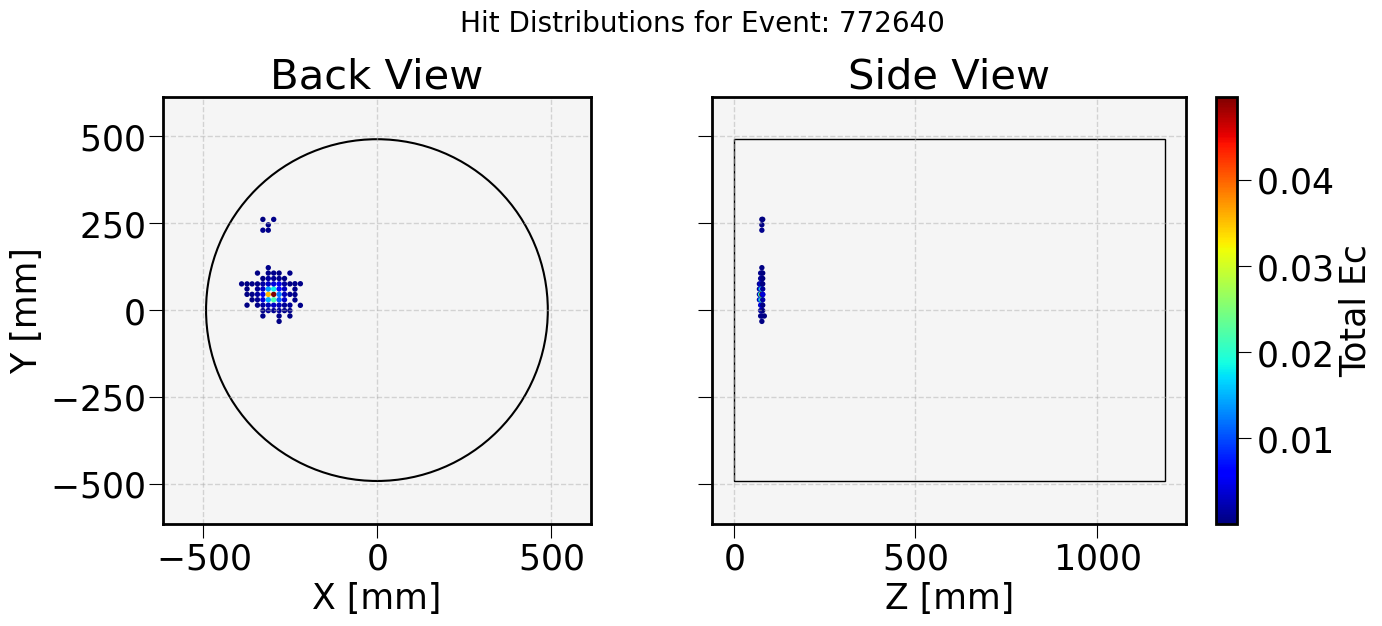

In [365]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(zero_s1_elec_like))

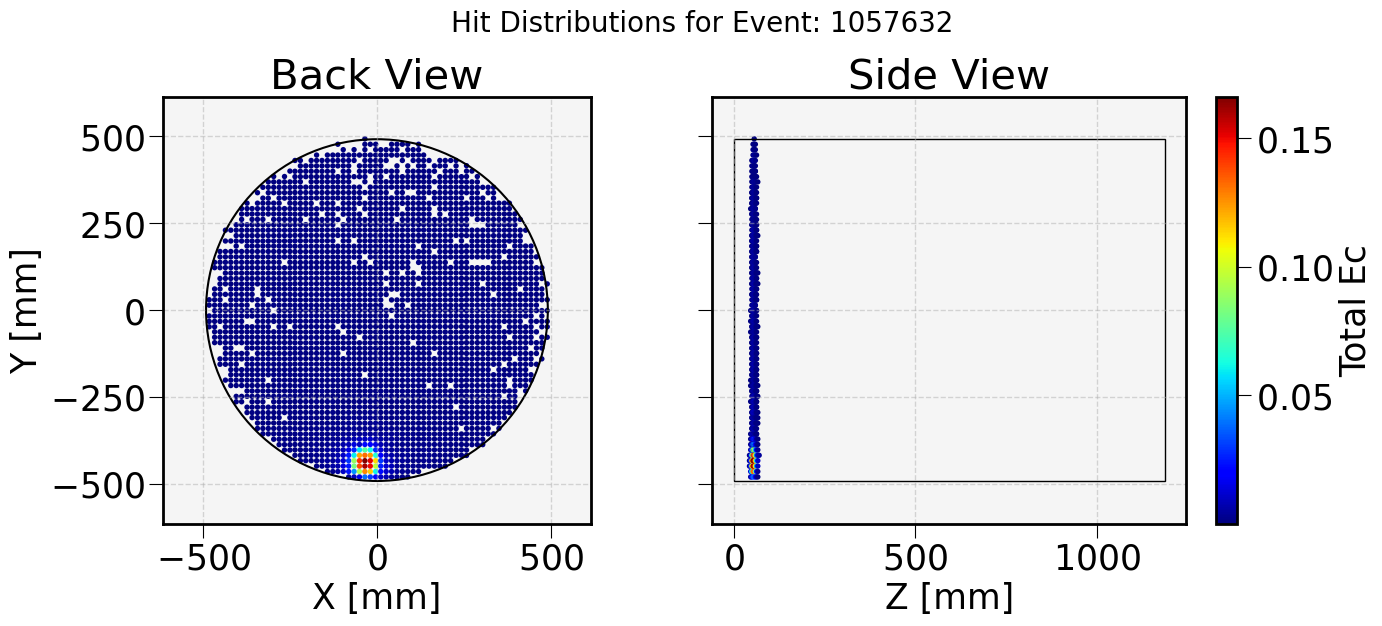

In [308]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(zero_s1_alpha_like))

### $nS1 = 1$

Here, the discriminator is the _max. corrected S1 energy_!

In [368]:
max_S1_corr_df = one_s1_events_df.groupby('event').agg(S1e_corr_max=('S1e_corr', 'max')).reset_index()

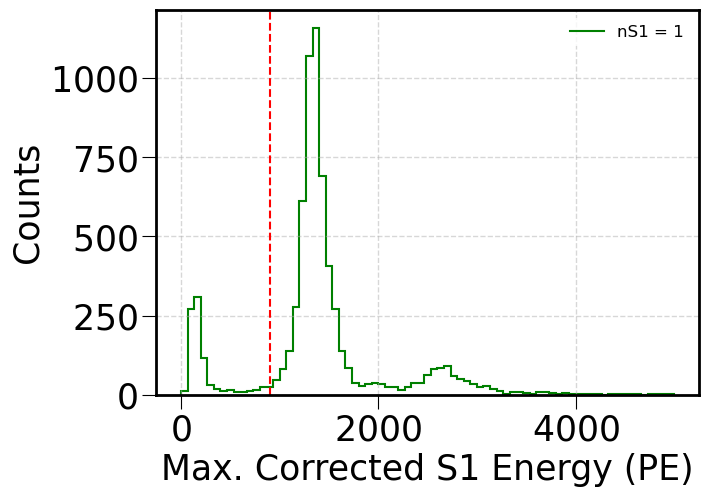

In [378]:
# Histogram
one_s1_counts, edges = np.histogram(max_S1_corr_df['S1e_corr_max'], bins=75, range=(0, 5e3))

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(one_s1_counts, edges, fill=False, ec='green', lw=1.5, label='nS1 = 1')
# S1e_corr cut
plt.axvline(x=S1_ENERGY_THRESHOLD, color='red', ls='--', lw=1.5)

# Styling
plt.xlabel('Max. Corrected S1 Energy (PE)')
plt.ylabel('Counts')
# plt.yscale('log')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [380]:
one_s1_elec_like  = max_S1_corr_df.loc[max_S1_corr_df['S1e_corr_max'] <= S1_ENERGY_THRESHOLD, 'event'].unique()
one_s1_alpha_like = max_S1_corr_df.loc[max_S1_corr_df['S1e_corr_max'] >  S1_ENERGY_THRESHOLD, 'event'].unique()
print(f"Number of electron-like events: {len(one_s1_elec_like)} ({len(one_s1_elec_like) / one_s1_events_df['event'].nunique() :.2%})")
print(f"Number of alpha-like events: {len(one_s1_alpha_like)} ({len(one_s1_alpha_like) / one_s1_events_df['event'].nunique() :.2%})")

Number of electron-like events: 875 (12.65%)
Number of alpha-like events: 6040 (87.35%)


Take a look to some event displays

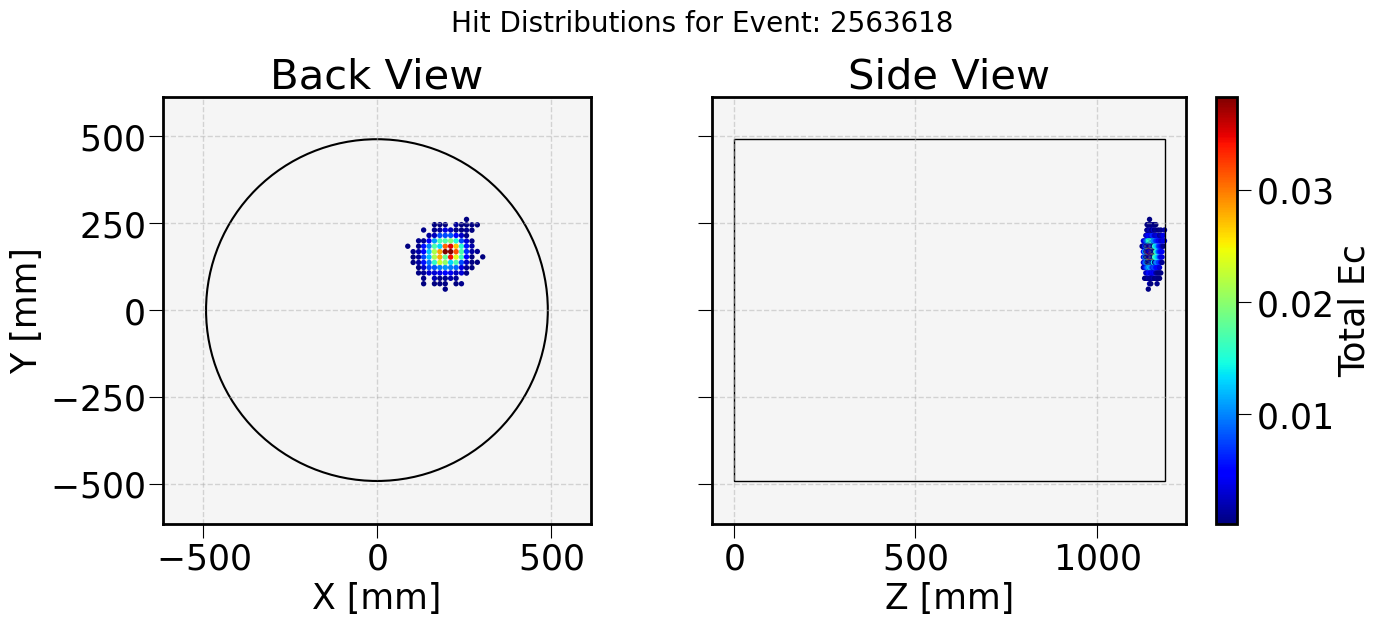

In [449]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(one_s1_elec_like))

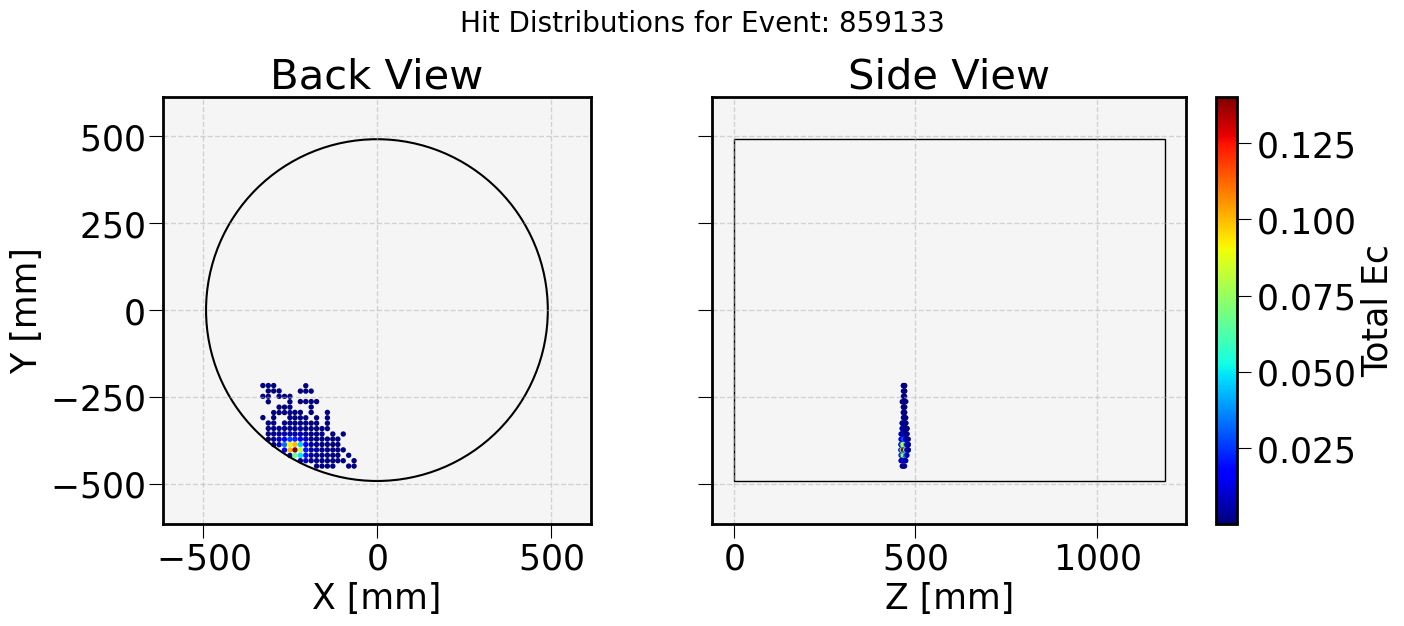

In [466]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(one_s1_alpha_like))

### Are we tagging properly?

In [468]:
print('In this test, we have...')
test_elec_ids  = np.union1d(zero_s1_elec_like, one_s1_elec_like)
test_alpha_ids = np.union1d(zero_s1_alpha_like, one_s1_alpha_like)
print(f" - {len(test_elec_ids)} electron-like events")
print(f" - {len(test_alpha_ids)} alpha-like events")

# ----- Tests ----- #
overlaped_events = np.intersect1d(test_elec_ids, test_alpha_ids)
if len(overlaped_events) > 0:
    print(f"ERROR: There are {len(overlaped_events)} overlaped events!\n       Event IDs: {overlaped_events.tolist()}")

untagged_events = np.setdiff1d(df_file['event'].unique(), np.union1d(test_elec_ids, test_alpha_ids))
if len(untagged_events) > 0:
    print(f"ERROR: There are {len(untagged_events)} untagged events!\n         Event IDs: {untagged_events}")

In this test, we have...
 - 1463 electron-like events
 - 6193 alpha-like events


### Execution

In [469]:
tagged_df_file = crudo.dm.tag_particles( df_file
                                       , size_threshold      = SIZE_THRESHOLD
                                       , s1_energy_threshold = S1_ENERGY_THRESHOLD
                                       , event_column        = 'event' )

In [470]:
# Split dataframes
electron_df = tagged_df_file[tagged_df_file['particle'] == 'electron'].copy()
alpha_df    = tagged_df_file[tagged_df_file['particle'] == 'alpha'].copy()
# Events ids
elec_ids  = electron_df.event.unique()
alpha_ids = alpha_df.event.unique()
print("After applying the tagging function, we have...")
print(f"  - {len(elec_ids)} electron-like events")
print(f"  - {len(alpha_ids)} alpha-like events")

# ----- Tests ----- #
if not np.array_equal(elec_ids, test_elec_ids):
    print("ERROR: Electron IDs do not match the test IDs!")
if not np.array_equal(alpha_ids, test_alpha_ids):
    print("ERROR: Alpha IDs do not match the test IDs!")

After applying the tagging function, we have...
  - 1463 electron-like events
  - 6193 alpha-like events


Let's see some event displays!

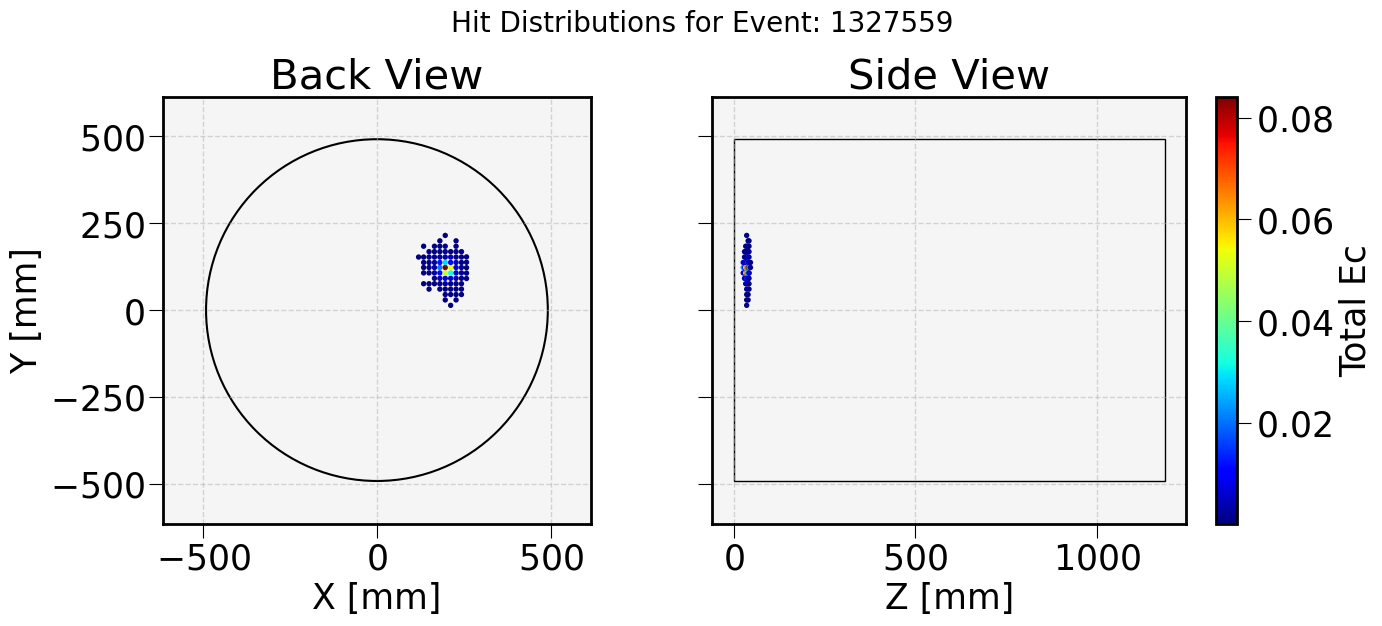

In [497]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(elec_ids))

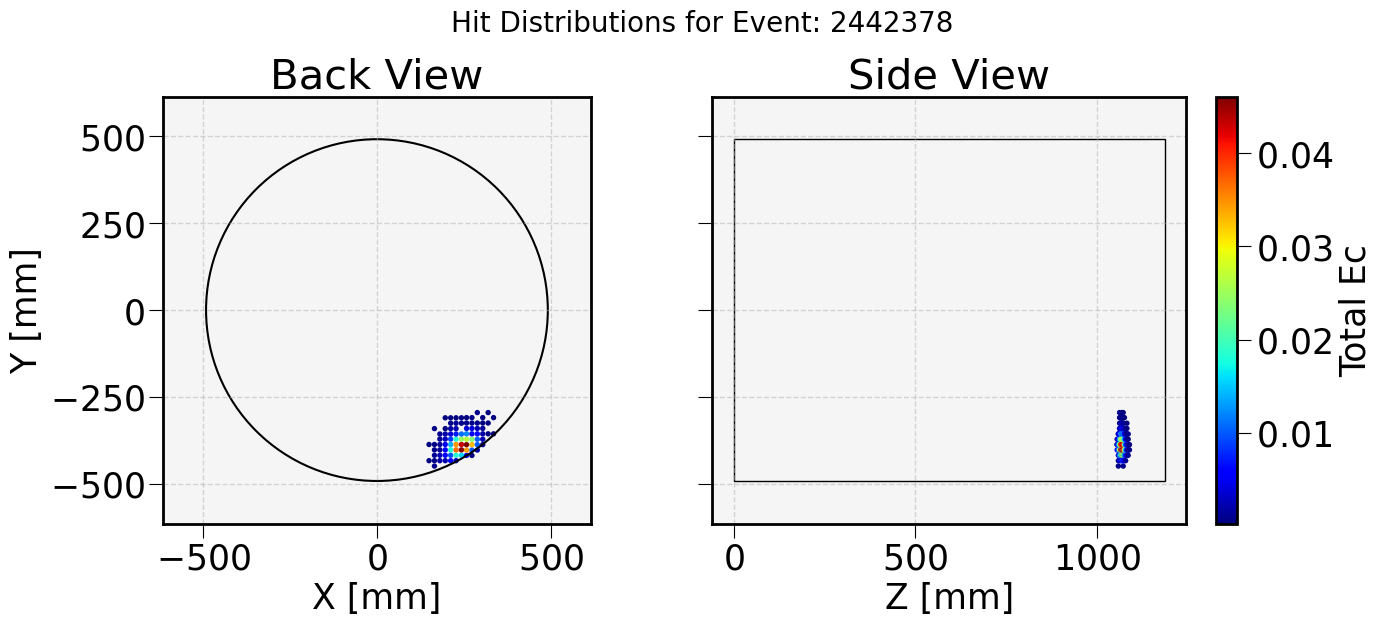

In [508]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(alpha_ids))

How is the energy spectrum?

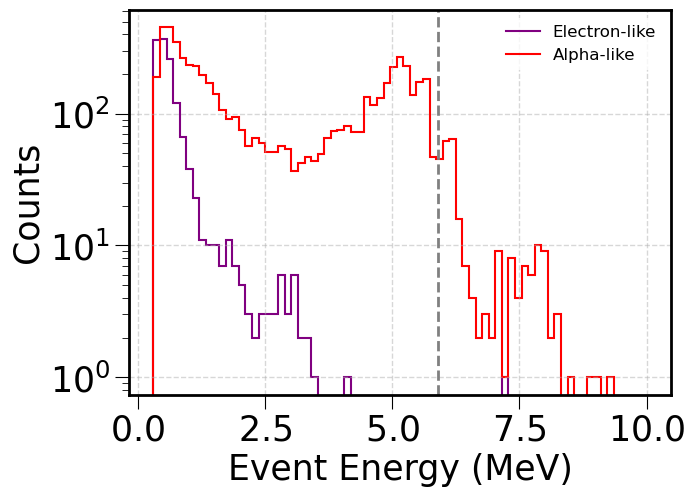

In [ ]:
# Histogram
alpha_counts, edges = np.histogram(alpha_df['E_evt'].unique(), bins=75, range=(alpha_df['E_evt'].min(), 10))
elec_counts, _      = np.histogram(electron_df['E_evt'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(elec_counts, edges, fill=False, ec='purple', lw=1.5, label='Electron-like')
plt.stairs(alpha_counts, edges, fill=False, ec='red', lw=1.5, label='Alpha-like')

# plt.axvline(x=5.9, color='gray', ls='--', lw=2.0)     # 222Rn energy

# Styling
plt.xlabel('Event Energy (MeV)')
plt.ylabel('Counts')
plt.yscale('log')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## By Detector Region

### Execution

In [511]:
region_tagged_df = crudo.dm.tag_event_by_detector_region( tagged_df_file
                                                        , z_cut_low=Z_LOW
                                                        , z_cut_high=Z_UP
                                                        , r_cut_high=R_UP
                                                        , event_column='event' )

Are these tags ok?

In [512]:
region_tagged_df

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max,particle,region
0,323,1,1,1143,1.759157e+09,762.313965,1313.382785,575.0,128.524979,1209250.0,...,170.735415,-297.025,458.925,-464.375,291.575,163.413097,179.322826,502.578458,alpha,tube
1,450,1,1,10018,1.759157e+09,1603.607910,1671.370030,850.0,269.178802,178875.0,...,1071.163302,-482.625,490.025,-479.925,492.725,1050.645651,1091.587939,510.216784,alpha,tube
2,1066,1,1,7983,1.759157e+09,1308.560181,1299.132857,375.0,226.088440,48550.0,...,1185.291068,-482.625,490.025,-479.925,492.725,1165.965829,1206.924985,498.389262,alpha,cathode
3,1591,1,1,549,1.759157e+09,93.521263,176.979598,575.0,17.189184,1353075.0,...,49.309786,-158.075,73.175,-479.925,-356.525,39.059832,72.838731,486.766639,electron,anode
4,1667,1,2,1824,1.759157e+09,1343.692505,2643.153689,1075.0,43.555904,42550.0,...,1186.748429,-235.825,381.175,-479.925,245.925,1170.258284,1207.719488,489.985317,alpha,cathode
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9329,3174159,1,1,515,1.759250e+09,1262.090942,1380.151966,700.0,217.700394,293500.0,...,963.669346,-482.625,-343.675,-62.575,153.125,949.784921,980.177561,491.115309,alpha,tube
9330,3174691,1,1,3658,1.759250e+09,1394.283936,1477.895662,675.0,228.198990,220925.0,...,1034.023386,-435.975,490.025,-479.925,446.075,1017.704938,1051.630454,494.520987,alpha,tube
9331,3174705,1,2,1902,1.759250e+09,1432.190552,4981.058013,825.0,59.096416,649275.0,...,661.442919,-389.325,381.175,-479.925,199.275,642.787555,680.294063,482.545911,alpha,tube
9332,3174705,1,2,1902,1.759250e+09,1432.190552,1820.304310,825.0,59.096416,649275.0,...,661.442919,-389.325,381.175,-479.925,199.275,642.787555,680.294063,482.545911,alpha,tube


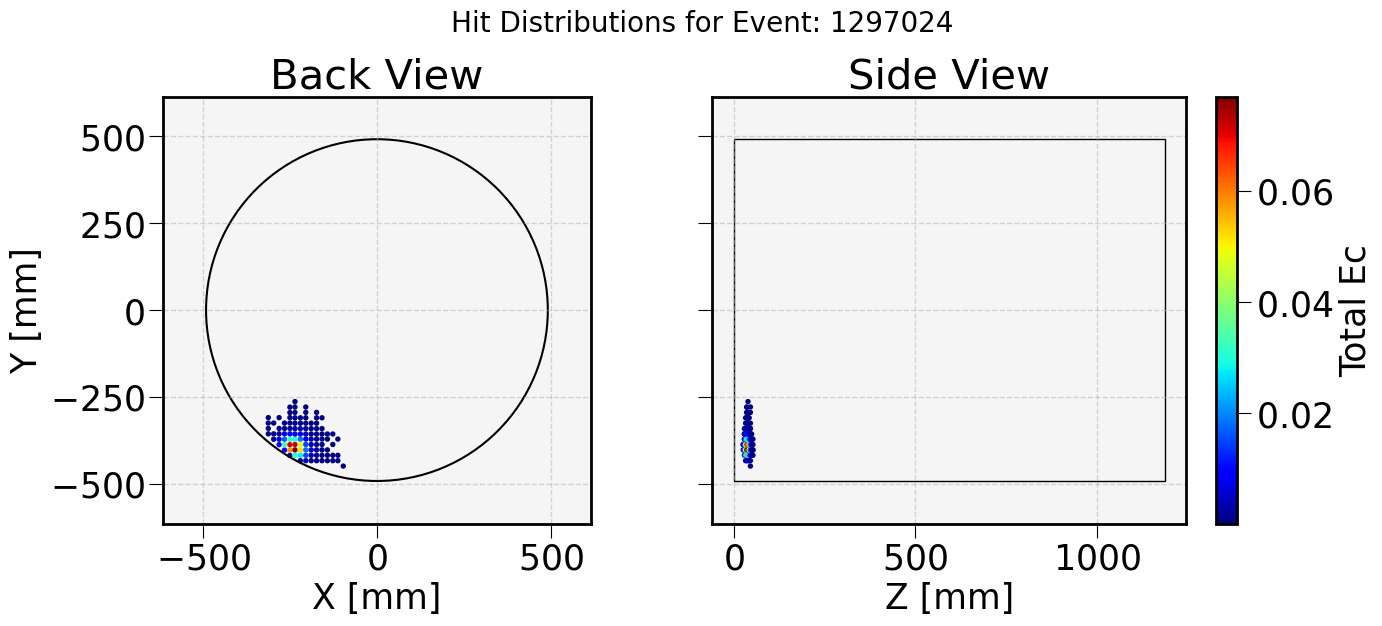

In [563]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(region_tagged_df.loc[region_tagged_df['region'] == 'anode', 'event'].unique()))

And also, let's find the event counters

In [564]:
detector_region_counts = df_file.groupby(['particle', 'region'])['event'].nunique()
detector_region_counts

particle  region  
alpha     anode        330
          cathode     2193
          fiducial       6
          tube        3664
electron  anode        649
          cathode      381
          fiducial     147
          tube         286
Name: event, dtype: int64

In [565]:
test_df = df_file[(df_file['particle'] == 'electron') & (df_file['region'] == 'cathode')].copy()
print(f"By using a dataframe: {test_df.event.nunique()}")
print(f"By using a series: {detector_region_counts.get(('electron', 'cathode'), 0)}")

# Verifiy if there are columns with uint64 type
uint64_columns = df_file.select_dtypes(include=['uint64']).columns
print("\nColumns with uint64 type:", uint64_columns)

By using a dataframe: 381
By using a series: 381

Columns with uint64 type: Index([], dtype='object')
